# Correlated disorder and the radiative loss of a photonic-crystal quasi-bound state in the continuum

**Hitesh Kumar Singh**
Department of Physics, Kurukshetra University, Kurukshetra, Haryana, India
Department of Physics, MNS Government College, Bhiwani, Haryana, India

This notebook is the complete computational record of the study. Run from top to bottom, it builds every structure, performs every electromagnetic calculation, writes every intermediate result to `results/`, draws every figure of the paper into `figures/`, and closes with the numbers quoted in the text. Reusable building blocks (geometry, solver calls, disorder synthesis, statistics, plotting) live in the `src/` package; everything specific to this study is written out in the cells below.

**Running the notebook.** Every stage that takes more than a few seconds stores its output as a JSON record in `results/`. If the record exists it is loaded, otherwise it is computed and saved. Setting `RECOMPUTE = True` in the setup cell regenerates all records. The linear-algebra libraries are restricted to one thread, which makes repeated runs on the same machine bitwise identical. Single-core run times of a full recomputation on the machine used for the study (about two hours in total):

| Stage | Section | Time |
|---|---|---|
| Parameter survey, momentum-space diagnostic, benchmarks | 4, 5 | 6 min |
| Plane-wave cutoff ladder and guided-mode enrichment | 6 | 12 min |
| Main ensemble grid (12 points, 40 realisations each) | 8 | 52 min |
| Supercell-size series and cutoff check | 8 | 45 min |
| Analysis and figures | 9 to 11 | 1 min |

**Contents.** 1 Physical background. 2 Computational method. 3 Setup and checks. 4 The structures. 5 Verification benchmarks. 6 Basis convergence. 7 Clean-band input for the model. 8 Disorder ensembles. 9 Analysis. 10 Figures. 11 Final results.

## 1. Physical background

### 1.1 Bound states in the continuum in a photonic-crystal slab

A photonic-crystal slab supports guided resonances: Bloch modes above the light line that leak into plane waves radiating out of the slab. At in-plane wavevector $\mathbf k$ a resonance decays at a rate set by its overlap with the radiating diffraction orders, and its quality factor is $Q = \mathrm{Re}\,f/(2\,\mathrm{Im}\,f)$.

At the $\Gamma$ point of a square lattice only the zeroth diffraction order radiates, and it transforms like the two-dimensional irreducible representation $E$ of the point group $C_{4v}$. Modes belonging to the one-dimensional representations cannot couple to it. They are symmetry-protected bound states in the continuum (BICs) with $Q = \infty$. Away from $\Gamma$ the protection is lost continuously: the radiative coupling grows linearly with $k = |\mathbf k|$, the radiative rate grows as $k^2$, and

$$Q(k) \propto k^{-2}, \qquad k \to 0 .$$

The far-field polarization of the band winds around the BIC, so the BIC carries an integer topological charge. When several charges are steered onto the $\Gamma$ point by tuning a structural parameter, the leading terms of the coupling cancel and the merged configuration obeys $Q \propto k^{-6}$. The exponent of $Q(k)$ in the limit $k \to 0$ is therefore what distinguishes an isolated BIC from a merged one.

### 1.2 Radiation induced by disorder

Fabrication disorder breaks the translational symmetry that protects the BIC. To lowest order a perturbation $\Delta\varepsilon(\mathbf r)$ with Fourier components $\Delta\varepsilon_{\mathbf q}$ mixes the BIC with Bloch modes at $\mathbf k = \mathbf q$. Two routes then lead to radiation. Components with $|\mathbf q| < k_0 = \omega/c$ scatter the BIC directly into radiating plane waves. Components with larger $|\mathbf q|$ admix leaky Bloch modes, from which the BIC inherits a radiative width. In both cases the rate is second order in the perturbation (Fermi golden rule): for disorder of standard deviation $\sigma$ the induced loss scales as $\sigma^2$, and its size is set by the disorder power spectrum $S(\mathbf q)$ where the coupling to radiation is strong.

This is why the spatial correlation of the disorder matters. At fixed variance $\sigma^2$ the correlation length $\ell_c$ redistributes spectral weight. White disorder spreads it evenly over all $q$; correlated disorder concentrates it at $q \lesssim 1/\ell_c$, near the $\Gamma$ point, where the band lies closest in frequency to the BIC.

### 1.3 The system studied

Structure A is a square lattice of air holes, radius $r = 0.18a$, in a slab of thickness $d = 0.782a$ and permittivity $\varepsilon = 12$ in air. Bands are numbered from 0 in order of increasing frequency, as in `legume`: band 0 is the fundamental guided band, which starts at $f = 0$, and band 1 is the lowest band above the light line at $\Gamma$. In the TE-like guided-mode basis, band 1 of structure A has a non-degenerate mode at $\Gamma$ with $f = \omega a/2\pi c \approx 0.324$ that is a symmetry-protected BIC. Disorder is applied to the hole radii of an $N \times 1$ supercell. Structure B differs only in thickness, $d = 0.9225a$; it enters the study through its clean-lattice $Q(k)$, because at a low plane-wave cutoff it shows the signature of a merged BIC (Sec. 9.11).

The notebook answers three questions.

1. How does the ensemble-mean loss depend on $\ell_c$ at fixed $\sigma$, measured by the enhancement ratio $R(\ell_c) = \langle 1/Q\rangle(\ell_c) / \langle 1/Q\rangle(0)$?
2. Does a first-order spectral-overlap model predict that dependence, and how does it change with supercell size $N$?
3. Is structure B a merged BIC, and what does a truncated plane-wave basis do to that diagnosis?

## 2. Computational method

### 2.1 Guided-mode expansion

The guided-mode expansion (GME) represents the magnetic field as a superposition of the guided modes $\alpha$ of an effective homogeneous slab of permittivity $\varepsilon_{\rm eff}$, taken at the wavevectors $\mathbf k + \mathbf G$ of the reciprocal lattice with $|\mathbf G| \le g_{\max}\,(2\pi/a)$:

$$\mathbf H(\mathbf r) = \sum_{\mathbf G,\alpha} c_{\mathbf G\alpha}\, \mathbf H^{\rm guided}_{\mathbf k+\mathbf G,\alpha}(\mathbf r).$$

The wave equation $\nabla \times \varepsilon^{-1}(\mathbf r)\, \nabla \times \mathbf H = (\omega/c)^2\, \mathbf H$ becomes the Hermitian eigenproblem

$$\sum_{\mathbf G'\alpha'} \mathcal H_{\mathbf G\alpha,\mathbf G'\alpha'}\; c_{\mathbf G'\alpha'} = \frac{\omega^2}{c^2}\; c_{\mathbf G\alpha},$$

whose eigenvalues give the real frequencies and whose eigenvectors are orthonormal. Modes above the light line couple to the radiative modes of the effective slab. Their imaginary frequency follows from the golden rule,

$$\mathrm{Im}\,\frac{\omega^2}{c^2} = -\pi \sum_{\mathbf G',\lambda,j} \left| \mathcal H^{\rm rad}_{\lambda j}(\mathbf k + \mathbf G') \right|^2 \rho_j\!\left(\mathbf k + \mathbf G', \frac{\omega^2}{c^2}\right),$$

where the sum runs over the diffraction orders inside the light cone, both polarizations $\lambda$ and both claddings $j$, and $\rho_j$ is the density of radiative states. The calculation is done with the open-source package `legume`.

Two parameters control the accuracy: the plane-wave cutoff $g_{\max}$ and the set of guided-mode indices kept in the basis. Production runs use $g_{\max} = 6.001$ and the fundamental TE-like mode only; Sec. 6 varies both.

By default `legume` builds the guided modes for $\varepsilon_{\rm eff}$ equal to the average permittivity of the layer, which changes slightly from one disordered realisation to the next. We fix $\varepsilon_{\rm eff}$ at the clean-supercell value, so that the clean and disordered calculations share one expansion basis and the overlaps used in Sec. 2.4 are well defined.

### 2.2 Supercell and scope

The supercell has lattice vectors $(Na, 0)$ and $(0, a)$. Its $\Gamma$ point collects the unit-cell Bloch modes at $k_m = 2\pi m/(Na)$, $m = 0, \dots, N-1$, folded back to zero wavevector. Every row of holes along $y$ is identical, so the disorder is one-dimensional and perfectly correlated transversally: the model is a disordered chain of identical rows, not a slab with two-dimensional disorder. Only the hole radii fluctuate, and the dielectric is lossless, so $Q$ is purely radiative.

### 2.3 Correlated disorder

The radius offsets $\delta r_i$, $i = 0, \dots, N-1$, form a stationary Gaussian sequence on a ring with covariance

$$C(m) = \langle \delta r_i\, \delta r_{i+m} \rangle = \sigma^2 \exp\!\left(-\frac{m_p^2}{2\ell_c^2}\right), \qquad m_p = \min(m, N-m),$$

and $\ell_c = 0$ denotes white noise. The sequence is generated by circulant spectral synthesis: with $S = \mathcal F[C]$ the discrete power spectrum and $w$ a vector of independent standard normal variables,

$$\delta r = \mathcal F^{-1}\!\left[\sqrt{S} \odot \mathcal F[w]\right],$$

which reproduces $C$ exactly in the ensemble. A Gaussian kernel on a ring is not always positive definite, so negative entries of $S$ are set to zero and $S$ is rescaled to restore $\langle S \rangle = \sigma^2$; the weight removed this way is measured below. The correlation length is limited to $\ell_c \le N/(2\sqrt 6)$, which keeps the wrap-around covariance $C(N/2)$ below $5\%$ of $\sigma^2$.

### 2.4 Loss estimators

Let $\mathbf u_c$ be the eigenvector of the clean BIC, with complex frequency $f_c$, and $\mathbf u_n$, $f_n$ the eigenvectors and complex frequencies of a disordered supercell in the same basis, with overlaps $p_n = |\mathbf u_c^\dagger \mathbf u_n|^2$. Two estimators of the disorder-broadened loss are computed for every realisation:

$$\frac{1}{Q_{\rm E1}} = \frac{2}{\mathrm{Re}\,f_c}\, \frac{\sum_n p_n\, \mathrm{Im}\,f_n}{\sum_n p_n}, \qquad \frac{1}{Q_{\rm E2}} = \frac{2\,\mathrm{Im}\,f_j}{\mathrm{Re}\,f_j},$$

where $j$ labels the mode with the largest overlap $p_j$. The projected estimator E1 is the decay rate of the clean mode expanded in the disordered eigenbasis; the maximum-overlap estimator E2 is the linewidth that a single-resonance fit would return. When the retained overlap $\sum_n p_n$ falls below 0.95 the number of computed eigenmodes is increased.

### 2.5 Spectral-overlap model

Treating the disorder to second order and keeping the Lorentzian response of each folded mode gives two channel weights,

$$D = \frac{2}{f_0} \sum_{0 < |k_m| < k_0} S_m, \qquad I = \frac{2}{f_0} \sum_{m \ne 0} S_m\, \frac{g_m}{(f_0 - f_m)^2 + g_m^2/4},$$

with $k_0 = 2\pi f_0$ the light line, $f_m$ and $g_m = 2\,\mathrm{Im}\,f_m$ the frequency and full width of the clean band at $k_m$, and the model

$$\langle 1/Q \rangle - 1/Q_{\rm clean} = A_d D + A_i I.$$

$D$ counts disorder components that scatter directly into radiation; $I$ counts admixture of leaky folded modes. The model assumes (T1) a direct coupling independent of $m$ inside the light cone and (T2) an indirect matrix element $|V_m|^2 = A_i S_m$ with one constant $A_i$ for all $m$. $A_d$ and $A_i$ are fitted, so the model is phenomenological. Its prediction for the enhancement ratio, $R_{\rm model}(\ell_c) = I(\ell_c)/I(0)$, contains no free parameter, because $A_i$ and $\sigma^2$ cancel.

### 2.6 Statistical treatment

The loss distribution is strongly right-skewed, so every ensemble mean carries a 95% percentile bootstrap interval. Ensembles at different correlation lengths use different seeds and are resampled independently; comparisons between plane-wave cutoffs reuse the seeds (common random numbers) and are resampled in pairs.

In the second-order regime the ratio $R(\ell_c)$ does not depend on $\sigma$, so the three disorder amplitudes are three measurements of one quantity. Their logarithms are combined with the DerSimonian-Laird random-effects estimator, and Cochran's heterogeneity statistic $Q_{\rm C}$ tests their consistency; a two-way fit of all twelve ensemble means (Sec. 9.3) avoids relying on a single white-disorder ensemble per amplitude. Power laws are fitted by weighted least squares in log-log form, and every exponent is quoted with its standard error multiplied by $\sqrt{\max(\chi^2/\nu, 1)}$. The distribution of the loss is summarised by the effective number of radiation channels $k_{\rm eff} = 2/\mathrm{CV}^2$, the value for which a $\chi^2$ distribution with $k_{\rm eff}$ degrees of freedom has the observed coefficient of variation. A simulation in Sec. 9.4 measures how well the bootstrap intervals cover the truth for distributions of this shape.

## 3. Setup and checks

In [1]:
import os
for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(var, "1")

import json
import platform
import time
from importlib import metadata
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Rectangle
from scipy import stats as sps

import legume
from src import config as C
from src import disorder, ensembles, geometry, gme, model, plotting, rcwa, records, stats

%matplotlib inline
plotting.apply_style()

RECOMPUTE = False          # True regenerates every record in results/
RESULTS = Path("results")
FIGURES = Path("figures")
REFERENCES = {}            # clean supercell solutions shared by the ensemble stages

environment = dict(
    python=platform.python_version(), platform=platform.platform(),
    threads=os.environ["OMP_NUM_THREADS"],
    packages={p: metadata.version(p) for p in
              ("numpy", "scipy", "matplotlib", "legume-gme", "grcwa")})
records.save(RESULTS / "environment.json", environment)
print(json.dumps(environment, indent=1))

{
 "python": "3.11.15",
 "platform": "Linux-6.18.44-fc-v37-x86_64-with-glibc2.39",
 "threads": "1",
 "packages": {
  "numpy": "2.4.4",
  "scipy": "1.17.1",
  "matplotlib": "3.10.9",
  "legume-gme": "1.0.3",
  "grcwa": "0.1.2"
 }
}


### 3.1 Checks of the disorder generator

The ensemble autocovariance of 4000 synthesised sequences is compared with the target covariance, and the spectral weight removed by the positivity clip is listed for every $(N, \ell_c)$ used in the study.

In [2]:
rng = np.random.default_rng(7)
acov = disorder.sample_autocov(4000, 32, 0.01, 2.0, rng)
target = disorder.target_cov(32, 0.01, 2.0)
generator_rms = float(np.sqrt(np.mean((acov - target) ** 2)) / 0.01 ** 2)
print(f"rms deviation of the sample autocovariance: {generator_rms:.4f} sigma^2 (4000 samples)")

clip = {}
for N in sorted(set(C.N_SIZES) | {C.N_MAIN}):
    for lc in C.LCS:
        if C.lc_allowed(lc, N):
            clip[f"N{N}_lc{lc:g}"] = disorder.psd_clip_weight(N, 0.01, lc)
clip_max = max(clip.values())
print("positivity-clip weight:", {k: f"{v:.1e}" for k, v in clip.items()})
print(f"largest clipped weight: {clip_max:.2e}")

rms deviation of the sample autocovariance: 0.0059 sigma^2 (4000 samples)
positivity-clip weight: {'N10_lc0': '-0.0e+00', 'N10_lc0.5': '-0.0e+00', 'N10_lc1': '-0.0e+00', 'N10_lc2': '5.4e-03', 'N12_lc0': '-0.0e+00', 'N12_lc0.5': '-0.0e+00', 'N12_lc1': '-0.0e+00', 'N12_lc2': '1.9e-03', 'N16_lc0': '-0.0e+00', 'N16_lc0.5': '-0.0e+00', 'N16_lc1': '-0.0e+00', 'N16_lc2': '4.2e-05'}
largest clipped weight: 5.43e-03


### 3.2 Checks of the building blocks

The assertions below protect properties on which the results rely: every realisation of the study has its own random seed, the disorder spectrum is non-negative and carries the variance $\sigma^2$, the RCWA permittivity grid reproduces the stripe widths exactly, the model channels scale as $\sigma^2$ and give $R = 1$ for white disorder, and the statistical routines return the exact answer for inputs whose answer is known. The notebook stops at the first failure.

In [3]:
seeds = [C.seed_for(1, g, r) for g, *_ in C.main_grid() for r in range(C.N_SEEDS_MAIN)]
seeds += [C.seed_for(1, g, r) for g, s, lc, N in C.size_grid() if N != C.N_MAIN
          for r in range(C.N_SEEDS_SIZE)]
seeds += [C.LADDER_SEED0 + i for i in range(C.N_SEEDS_LADDER)]
assert len(seeds) == len(set(seeds))
for args in ((1, C.GRID_INDEX_MAX, 0), (1, 0, C.REPLICATE_MAX)):
    try:
        C.seed_for(*args)
        raise AssertionError(f"seed_for{args} should be rejected")
    except ValueError:
        pass

for N in sorted(set(C.N_SIZES) | {C.N_MAIN}):
    for lc in C.LCS:
        S = disorder.psd(N, 0.01, lc)
        assert S.min() >= 0 and abs(S.mean() / 0.01 ** 2 - 1) < 1e-12

for delta in (0.04, 0.06, 0.10):
    eps_grid = rcwa.grating_profile(0.45, delta, 12.0)
    filled = (eps_grid - 1) / 11 * (2 / eps_grid.size)
    half = eps_grid.size // 2
    assert abs(filled[:half].sum() - 0.45 * (1 - delta / 2)) < 1e-12
    assert abs(filled[half:].sum() - 0.45 * (1 + delta / 2)) < 1e-12

k_syn = model.folded_k(12)
f_syn, g_syn = 0.32 + 0.02 * k_syn ** 2, 1e-3 * k_syn ** 2
D1, I1 = model.channels(12, 0.01, 1.0, 0.32, f_syn, g_syn)
D2, I2 = model.channels(12, 0.02, 1.0, 0.32, f_syn, g_syn)
assert np.isclose(D2, 4 * D1) and np.isclose(I2, 4 * I1)
assert np.isclose(model.ratio_prediction(12, 0.0, 0.32, f_syn, g_syn), 1.0)

x = np.random.default_rng(1).chisquare(3, 40)
same = stats.ratio_ci(x, x, paired=True)
assert same["ratio"] == same["lo"] == same["hi"] == 1.0
xs = np.array([1.0, 2.0, 4.0, 8.0])
assert np.isclose(stats.wls_loglog(xs, 3 * xs ** -2, 0.1 * xs ** -2)["slope"], -2.0)
pool = stats.pool_log_ratios([0.2, 0.2, 0.2], [0.1, 0.2, 0.3])
assert np.isclose(pool["random"], 0.2) and pool["Q"] < 1e-20 and pool["I2"] == 0.0
print(f"all checks passed ({len(seeds)} distinct seeds)")

all checks passed (650 distinct seeds)


## 4. The structures

### 4.1 Survey of the parameter space

To place structures A and B in context we compute $Q(k)$ of band 1 along $\Gamma$X for 110 unit cells: the TE-like and the TM-like fundamental guided-mode basis, five hole radii and eleven slab thicknesses, at ten wavevectors between $10^{-4}$ and $0.2$ (in units of $1/a$). A single power law is fitted to each $Q(k)$. The survey asks whether any geometry in this range shows the steep $k^{-6}$ scaling of a merged BIC.

In [4]:
KS_SCAN = np.geomspace(1e-4, 0.2, 10)


def structure_scan():
    rows = []
    for gmode in C.GMODE_SURVEY:
        for r in C.R_SCAN:
            for d in C.D_SCAN:
                f, _, Q = gme.band_q(d, r, gmode, KS_SCAN)
                fit = stats.powerlaw_fit(KS_SCAN, Q)
                rows.append(dict(gmode=gmode, r=r, d=d, f_gamma=float(f[0]),
                                 q_kmin=float(Q[0]), exponent=fit["slope"],
                                 misfit_factor=fit["misfit_factor"]))
    return dict(ks=KS_SCAN, gmax=C.GMAX_PROD, band=C.SCAN_BAND, candidates=rows)


t0 = time.time()
scan = records.cached(RESULTS / "structure_scan.json", structure_scan, RECOMPUTE)
cand = scan["candidates"]
exps = np.array([c["exponent"] for c in cand])
print(f"{len(cand)} candidates ({time.time() - t0:.0f} s); fitted exponents from "
      f"{exps.min():.2f} to {exps.max():.2f}; steeper than -4: {int(np.sum(exps < -4))}")
for tag, cfg in C.STRUCTURES.items():
    c = next(c for c in cand if c["gmode"] == cfg["gmode"] and c["r"] == cfg["r"] and c["d"] == cfg["d"])
    print(f"structure {tag}: f(Gamma) = {c['f_gamma']:.4f}, Q(k = 1e-4) = {c['q_kmin']:.2e}, "
          f"exponent {c['exponent']:.2f}, misfit factor {c['misfit_factor']:.2f}")
top = sorted(cand, key=lambda c: -c["q_kmin"])[:3]
print("largest Q(k = 1e-4) in the survey:")
for c in top:
    print(f"   gmode {c['gmode']}, r = {c['r']}, d = {c['d']}: Q = {c['q_kmin']:.2e}, "
          f"exponent {c['exponent']:.2f}, misfit factor {c['misfit_factor']:.2f}")

110 candidates (0 s); fitted exponents from -2.23 to -1.74; steeper than -4: 0
structure A: f(Gamma) = 0.3242, Q(k = 1e-4) = 7.03e+10, exponent -2.01, misfit factor 1.09
structure B: f(Gamma) = 0.3180, Q(k = 1e-4) = 4.93e+11, exponent -1.98, misfit factor 1.22
largest Q(k = 1e-4) in the survey:
   gmode [0], r = 0.22, d = 0.9225: Q = 1.87e+14, exponent -2.23, misfit factor 4.27
   gmode [0], r = 0.22, d = 0.92: Q = 2.09e+13, exponent -2.11, misfit factor 2.12
   gmode [0], r = 0.14, d = 0.88: Q = 5.96e+12, exponent -1.77, misfit factor 9.30


### 4.2 Momentum-space diagnostic of structures A and B

An isolated BIC gives $Q \propto k^{-2}$ and a merged BIC $Q \propto k^{-6}$ as $k \to 0$. The exponent is fitted over the decade $k \in [10^{-4}, 10^{-3}]$ at four plane-wave cutoffs. $Q(k)$ over $[10^{-4}, 0.3]$ is stored as well, together with the same data for the two survey geometries with the largest $Q$ at the smallest wavevector, which show whether an anomalously large $Q$ survives basis enrichment.

In [5]:
KS_ASYM = np.geomspace(1e-4, 1e-3, 6)
KS_FULL = np.geomspace(1e-4, 0.3, 16)
GMAX_DIAG = (4.001, 5.001, 6.001, 8.001)
OUTLIERS = [dict(label=f"r{c['r']:g}_d{c['d']:g}", r=c["r"], d=c["d"], gmode=c["gmode"])
            for c in top if not any(c["r"] == s["r"] and c["d"] == s["d"] and c["gmode"] == s["gmode"]
                                    for s in C.STRUCTURES.values())][:2]


def momentum_diagnostic():
    geoms = [dict(label=tag, r=cfg["r"], d=cfg["d"], gmode=cfg["gmode"])
             for tag, cfg in C.STRUCTURES.items()] + OUTLIERS
    out = dict(ks_asymptotic=KS_ASYM, ks_full=KS_FULL, cutoffs=GMAX_DIAG, geometries={})
    for g in geoms:
        entry = dict(r=g["r"], d=g["d"], gmode=g["gmode"], q_asymptotic={}, q_full={})
        for gmax in GMAX_DIAG:
            entry["q_asymptotic"][f"{gmax:g}"] = gme.band_q(g["d"], g["r"], g["gmode"], KS_ASYM, gmax=gmax)[2]
            entry["q_full"][f"{gmax:g}"] = gme.band_q(g["d"], g["r"], g["gmode"], KS_FULL, gmax=gmax)[2]
        out["geometries"][g["label"]] = entry
    return out


momentum = records.cached(RESULTS / "momentum_diagnostic.json", momentum_diagnostic, RECOMPUTE)
print(f"{'geometry':>14s} " + " ".join(f"{'g=' + k:>16s}" for k in momentum["geometries"]["A"]["q_asymptotic"]))
for label, e in momentum["geometries"].items():
    ex = [stats.powerlaw_fit(momentum["ks_asymptotic"], q)["slope"] for q in e["q_asymptotic"].values()]
    print(f"{label:>14s} " + " ".join(f"{x:16.3f}" for x in ex))

      geometry          g=4.001          g=5.001          g=6.001          g=8.001
             A           -2.000           -2.000           -2.000           -2.000
             B           -2.000           -2.000           -2.000           -2.000
 r0.22_d0.9225           -2.000           -2.000           -2.000           -2.000
   r0.22_d0.92           -2.000           -2.000           -2.000           -2.000


The Γ-point modes of the two unit cells (computed at $k_x a = 10^{-4}$, production cutoff) place the BIC among its neighbours. Band 0, the fundamental guided band at $f \approx 0$, is omitted.

In [6]:
gamma_spectrum = {}
for tag, cfg in C.STRUCTURES.items():
    s = gme.run(geometry.unit_cell(cfg["d"], cfg["r"]), [list(C.KPOINT_GAMMA)], cfg["gmode"], 8)
    modes = zip(np.array(s.freqs[0])[1:], gme.quality_factors(s)[1:])
    gamma_spectrum[tag] = [dict(f=float(f), Q=float(q)) for f, q in modes]
    print(f"structure {tag}: " + ", ".join(f"f = {m['f']:.4f} (Q = {m['Q']:.2e})" for m in gamma_spectrum[tag]))

structure A: f = 0.3242 (Q = 7.03e+10), f = 0.3300 (Q = 6.40e+10), f = 0.3521 (Q = 4.13e+03), f = 0.3521 (Q = 4.13e+03), f = 0.4470 (Q = 6.19e+10), f = 0.4579 (Q = 4.25e+10), f = 0.4910 (Q = 4.65e+02)


structure B: f = 0.3180 (Q = 4.93e+11), f = 0.3237 (Q = 1.07e+11), f = 0.3457 (Q = 6.00e+02), f = 0.3457 (Q = 6.00e+02), f = 0.4413 (Q = 5.96e+10), f = 0.4521 (Q = 4.35e+10), f = 0.4850 (Q = 5.10e+02)


## 5. Verification benchmarks

### 5.1 Zero index contrast

With the holes filled by slab material the supercell is a uniform slab. Its folded bands must coincide with those of the unpatterned slab and carry no radiative loss.

In [7]:
N, d = 4, 0.5
ks = [list(C.KPOINT_GAMMA)] + [[k, 0.0] for k in (0.3, 0.7, 1.1, 1.5)]
filled = gme.run(geometry.supercell(N, d, 0.25, eps_hole=C.EPS_SLAB), ks, [0], 10)
slab = legume.PhotCryst(legume.Lattice([N, 0], [0, 1]))
slab.add_layer(d=d, eps_b=C.EPS_SLAB)
uniform = gme.run(slab, ks, [0], 10)
f1, f2 = np.array(filled.freqs), np.array(uniform.freqs)
mask = f2 > 1e-6
zero_contrast = dict(max_rel_freq_diff=float(np.max(np.abs(f1[mask] - f2[mask]) / f2[mask])),
                     max_im_freq=float(np.max(np.array(filled.freqs_im))))
print(zero_contrast)

{'max_rel_freq_diff': 0.0, 'max_im_freq': 0.0}


### 5.2 Asymmetry law of a quasi-BIC

A two-hole basis with radii $r_0(1 \mp \alpha/2)$ turns a BIC of the square lattice into a quasi-BIC whose radiative rate is proportional to $\alpha^2$ for small asymmetry. The quasi-BIC is followed from $\alpha = 0$ by continuity in frequency; the fitted exponent of $1/Q$ against $\alpha$ must equal $2.00 \pm 0.15$.

In [8]:
ASYM = dict(d=0.5, r0=0.25, gmode=[1], numeig=12,
            alphas=(0.02, 0.04, 0.08, 0.12, 0.16, 0.20))


def gamma_modes(alpha):
    solver = gme.run(geometry.dimer_cell(ASYM["d"], ASYM["r0"], alpha),
                     [list(C.KPOINT_GAMMA)], ASYM["gmode"], ASYM["numeig"])
    return np.array(solver.freqs[0]), gme.quality_factors(solver)


def asymmetry_law():
    f_dark, Q_dark = gamma_modes(0.0)
    dark = [f for f, q in zip(f_dark, Q_dark) if f > C.F_MIN and (np.isinf(q) or q > 1e9)]
    rows, f_prev = [], None
    for alpha in ASYM["alphas"]:
        f, Q = gamma_modes(alpha)
        best = None
        for fd in dark:
            ref = fd if f_prev is None else f_prev
            near = sorted((abs(fi - ref), fi, qi) for fi, qi in zip(f, Q)
                          if np.isfinite(qi) and qi > 10 and abs(fi - ref) < 0.03)
            if near:
                _, fi, qi = max(near[:4], key=lambda t: t[2])
                if best is None or qi > best[1]:
                    best = (fi, qi)
        rows.append(dict(alpha=alpha, f=float(best[0]), Q=float(best[1])))
        f_prev = best[0]
    return dict(**ASYM, rows=rows)


asym = records.cached(RESULTS / "benchmark_asymmetry.json", asymmetry_law, RECOMPUTE)
alpha = np.array([r["alpha"] for r in asym["rows"]])
inv_q_alpha = np.array([1 / r["Q"] for r in asym["rows"]])
asym_fit = stats.wls_loglog(alpha, inv_q_alpha, 0.02 * inv_q_alpha)
print(f"1/Q ~ alpha^{asym_fit['slope']:.3f} +/- {asym_fit['se_inflated']:.3f}; "
      f"Q from {min(1 / inv_q_alpha):.2e} to {max(1 / inv_q_alpha):.2e}; "
      f"pass: {abs(asym_fit['slope'] - 2) <= 0.15}")

1/Q ~ alpha^2.011 +/- 0.010; Q from 3.01e+10 to 3.10e+12; pass: True


### 5.3 Comparison with rigorous coupled-wave analysis

The perturbative radiative rate of the GME is compared with an independent full-wave calculation. A period-$2a$ grating of dielectric stripes ($\varepsilon = 12$, thickness $0.5a$, widths $0.45a(1 \mp \delta/2)$) has a quasi-BIC whose $Q$ grows as the width asymmetry $\delta$ decreases. Its quality factor is obtained from the GME and, independently, from a Fano fit of the normal-incidence reflectance computed by rigorous coupled-wave analysis (RCWA, `grcwa`, 101 diffraction orders). The RCWA permittivity grid averages each pixel over the two media, so the stripe widths, and hence $\delta$, are represented exactly. This matters because $Q \propto \delta^{-2}$: rounding the stripe edges to whole pixels would change $\delta$, and $Q$ with it, by an amount that grows as $\delta$ decreases. Six asymmetries span $Q$ from about $10^2$ to $2\times10^4$. The criterion is a worst-case deviation below 30%. The frequency offset between the two methods and the change of the RCWA result with 151 diffraction orders are recorded as well.

In [9]:
GRATING = dict(d=0.5, w=0.45, eps=12.0, gmode=[0], deltas=(0.40, 0.25, 0.15, 0.10, 0.06, 0.04))


def gme_grating(delta):
    solver = gme.run(geometry.stripe_dimer_cell(GRATING["d"], GRATING["w"], delta),
                     [list(C.KPOINT_GAMMA)], GRATING["gmode"], 8)
    f, Q = np.array(solver.freqs[0]), gme.quality_factors(solver)
    cand = [(fi, qi) for fi, qi in zip(f, Q) if 0.15 < fi < 0.30 and np.isfinite(qi) and 50 < qi < 1e7]
    return max(cand, key=lambda t: t[1])


def rcwa_benchmark():
    rows, shift = [], None
    for delta in GRATING["deltas"]:
        f_g, q_g = gme_grating(delta)
        f_guess = f_g if shift is None else f_g * shift
        q_r, f_r, _, resid = rcwa.resonance_q(f_guess, q_g, GRATING["d"], GRATING["w"], delta,
                                              GRATING["eps"])
        shift = f_r / f_g
        rows.append(dict(delta=delta, f_gme=float(f_g), Q_gme=float(q_g), f_rcwa=f_r, Q_rcwa=q_r,
                         fit_rms=resid))
        print(f"   delta = {delta:.2f}: Q_GME = {q_g:.3e}, Q_RCWA = {q_r:.3e}", flush=True)
    ref = rows[3]
    q151 = rcwa.resonance_q(ref["f_rcwa"], ref["Q_rcwa"], GRATING["d"], GRATING["w"], ref["delta"],
                            GRATING["eps"], n_orders=151)[0]
    order_check = dict(delta=ref["delta"], Q_101=ref["Q_rcwa"], Q_151=q151)
    return dict(**GRATING, n_orders=101, rows=rows, order_check=order_check)


rcwa_bench = records.cached(RESULTS / "benchmark_rcwa.json", rcwa_benchmark, RECOMPUTE)
for r in rcwa_bench["rows"]:
    r["dev_Q"] = abs(r["Q_gme"] - r["Q_rcwa"]) / r["Q_rcwa"]
    r["dev_f"] = (r["f_gme"] - r["f_rcwa"]) / r["f_rcwa"]
    print(f"delta = {r['delta']:.2f}: Q_RCWA = {r['Q_rcwa']:9.1f}  |dQ|/Q = {r['dev_Q']:.3f}  "
          f"(f_GME - f_RCWA)/f_RCWA = {r['dev_f']:+.4f}")
q_r = np.array([r["Q_rcwa"] for r in rcwa_bench["rows"]])
dev_q = np.array([r["dev_Q"] for r in rcwa_bench["rows"]])
oc = rcwa_bench["order_check"]
rcwa_summary = dict(q_range=[float(q_r.min()), float(q_r.max())], worst_dev=float(dev_q.max()),
                    mean_dev=float(dev_q.mean()),
                    mean_freq_offset=float(np.mean([r["dev_f"] for r in rcwa_bench["rows"]])),
                    order_change=float(abs(oc["Q_151"] / oc["Q_101"] - 1)),
                    passed=bool(dev_q.max() <= 0.30))
print(rcwa_summary)

delta = 0.40: Q_RCWA =     172.2  |dQ|/Q = 0.043  (f_GME - f_RCWA)/f_RCWA = +0.0227
delta = 0.25: Q_RCWA =     452.7  |dQ|/Q = 0.027  (f_GME - f_RCWA)/f_RCWA = +0.0224
delta = 0.15: Q_RCWA =    1270.1  |dQ|/Q = 0.020  (f_GME - f_RCWA)/f_RCWA = +0.0218
delta = 0.10: Q_RCWA =    2866.1  |dQ|/Q = 0.019  (f_GME - f_RCWA)/f_RCWA = +0.0215
delta = 0.06: Q_RCWA =    7976.1  |dQ|/Q = 0.018  (f_GME - f_RCWA)/f_RCWA = +0.0213
delta = 0.04: Q_RCWA =   17961.1  |dQ|/Q = 0.017  (f_GME - f_RCWA)/f_RCWA = +0.0213
{'q_range': [172.16170646194493, 17961.127248184697], 'worst_dev': 0.04276489892073086, 'mean_dev': 0.023895937908071433, 'mean_freq_offset': 0.02181215128461894, 'order_change': 0.000661711128083553, 'passed': True}


## 6. Basis convergence

### 6.1 Plane-wave cutoff

The same ten disorder realisations ($N = 12$, $\sigma = 0.01a$, $\ell_c = a$) are solved at five plane-wave cutoffs. Reusing the seeds removes realisation-to-realisation noise from the comparison. The criterion is a change below 10% in $\langle 1/Q \rangle$ and below 0.2% in the frequency between successive cutoffs; the plateau is the smallest cutoff from which every later increment meets it.

In [10]:
LADDER = dict(N=C.N_MAIN, sigma=0.01, lc=1.0)


def cutoff_ladder():
    ladder = []
    for gmax in C.GMAX_LADDER:
        ref = gme.Reference("A", LADDER["N"], gmax)
        rows = [gme.realization(ref, LADDER["sigma"], LADDER["lc"], C.LADDER_SEED0 + i)
                for i in range(C.N_SEEDS_LADDER)]
        ladder.append(dict(gmax=gmax, f0=ref.f0, inv_q=[r["inv_q_proj"] for r in rows],
                           inv_q_mode_mean=float(np.mean([r["inv_q_mode"] for r in rows]))))
    return dict(structure="A", **LADDER, seed0=C.LADDER_SEED0, n_seeds=C.N_SEEDS_LADDER,
                ladder=ladder)


conv = records.cached(RESULTS / "convergence_ladder.json", cutoff_ladder, RECOMPUTE)
steps = []
for a, b in zip(conv["ladder"], conv["ladder"][1:]):
    ma, mb = np.mean(a["inv_q"]), np.mean(b["inv_q"])
    step = dict(g_from=a["gmax"], g_to=b["gmax"], d_inv_q=abs(mb - ma) / ma,
                d_f=abs(b["f0"] - a["f0"]) / a["f0"],
                paired=stats.ratio_ci(b["inv_q"], a["inv_q"], paired=True))
    step["passed"] = bool(step["d_inv_q"] < 0.10 and step["d_f"] < 0.002)
    steps.append(step)
    print(f"g_max {a['gmax']:g} -> {b['gmax']:g}: change in <1/Q> {100 * step['d_inv_q']:5.1f}%, "
          f"in f {100 * step['d_f']:.3f}%, paired ratio {step['paired']['ratio']:.3f} "
          f"[{step['paired']['lo']:.3f}, {step['paired']['hi']:.3f}], meets criterion: {step['passed']}")
plateau = next((s["g_to"] for i, s in enumerate(steps) if all(t["passed"] for t in steps[i:])), None)
ladder_drift = np.mean(conv["ladder"][0]["inv_q"]) / np.mean(conv["ladder"][-1]["inv_q"])
print(f"plateau reached at g_max = {plateau}; <1/Q>(4.001) / <1/Q>(8.001) = {ladder_drift:.2f}")

g_max 4.001 -> 5.001: change in <1/Q>   7.4%, in f 0.058%, paired ratio 0.926 [0.904, 0.955], meets criterion: True
g_max 5.001 -> 6.001: change in <1/Q>  27.5%, in f 0.006%, paired ratio 0.725 [0.704, 0.744], meets criterion: False
g_max 6.001 -> 7.001: change in <1/Q>  10.1%, in f 0.011%, paired ratio 0.899 [0.866, 0.932], meets criterion: False
g_max 7.001 -> 8.001: change in <1/Q>   4.9%, in f 0.031%, paired ratio 0.951 [0.937, 0.971], meets criterion: True
plateau reached at g_max = 8.001; <1/Q>(4.001) / <1/Q>(8.001) = 1.74


### 6.2 Guided-mode basis

The production basis contains only the fundamental TE-like guided mode. Adding the fundamental TM-like mode (index 1) or the second TE-like mode (index 2) enlarges the basis. For a slab that is symmetric under $z \to -z$, vertical parity decouples the fundamental TE-like mode from those additions at the $\Gamma$ point. We test this directly: the tracked mode is identified by frequency, the weight of its eigenvector on the added blocks is measured, and a small ensemble ($N = 8$, eight realisations) is solved in both bases.

In [11]:
def added_block_weights(phc_builder, f_ref, f_win, numeig):
    base = gme.run(phc_builder(), [list(C.KPOINT_GAMMA)], C.GMODE_PROD, numeig, eig_sigma=f_ref)
    n_base = np.array(base.eigvecs[0]).shape[0]
    window = (f_ref - f_win, f_ref + f_win)
    q_base = gme.quality_factors(base)[gme.find_mode(base, window, "nearest_f", f_ref)]
    out = {}
    for gm in ([0, 1], C.GMODE_ENRICHED):
        s = gme.run(phc_builder(), [list(C.KPOINT_GAMMA)], gm, 2 * numeig, eig_sigma=f_ref)
        n = gme.find_mode(s, window, "nearest_f", f_ref)
        out[str(gm)] = dict(weight_outside=gme.outside_block_weight(s, n, n_base),
                            q_ratio=float(gme.quality_factors(s)[n] / q_base))
    return out


def basis_enrichment():
    probe = {}
    for label, gm in (("base", C.GMODE_PROD), ("enriched", C.GMODE_ENRICHED)):
        ref = gme.Reference("A", 8, C.GMAX_PROD, gmode=gm, select="nearest_f")
        rows = [gme.realization(ref, 0.01, 1.0, C.LADDER_SEED0 + i) for i in range(8)]
        probe[label] = dict(gmode=gm, f0=ref.f0, inv_q=[r["inv_q_proj"] for r in rows])
    weights = {}
    for tag, cfg in C.STRUCTURES.items():
        weights[f"{tag}_unit_cell"] = added_block_weights(
            lambda cfg=cfg: geometry.unit_cell(cfg["d"], cfg["r"]), cfg["f0"], cfg["f_win"], 6)
    cfg = C.STRUCTURES["A"]
    weights["A_supercell_N8"] = added_block_weights(
        lambda: geometry.supercell(8, cfg["d"], cfg["r"]), cfg["f0"], cfg["f_win"], 16)
    return dict(probe=probe, block_weights=weights)


enrich = records.cached(RESULTS / "basis_enrichment.json", basis_enrichment, RECOMPUTE)
p = enrich["probe"]
enrich_change = abs(np.mean(p["enriched"]["inv_q"]) / np.mean(p["base"]["inv_q"]) - 1)
enrich_df = abs(p["enriched"]["f0"] - p["base"]["f0"]) / p["base"]["f0"]
print(f"ensemble mean changes by {enrich_change:.1e}, mode frequency by {enrich_df:.1e}")
for key, val in enrich["block_weights"].items():
    print(key, {k: f"weight {v['weight_outside']:.1e}, Q ratio {v['q_ratio']:.12f}" for k, v in val.items()})
block_weight_max = max(v["weight_outside"] for val in enrich["block_weights"].values() for v in val.values())

ensemble mean changes by 6.1e-13, mode frequency by 8.9e-15
A_unit_cell {'[0, 1]': 'weight 6.5e-30, Q ratio 1.000000000685', '[0, 2]': 'weight 2.6e-28, Q ratio 1.000000000315'}
B_unit_cell {'[0, 1]': 'weight 1.8e-30, Q ratio 0.999999999386', '[0, 2]': 'weight 1.8e-27, Q ratio 1.000000000925'}
A_supercell_N8 {'[0, 1]': 'weight 2.5e-29, Q ratio 0.999999998215', '[0, 2]': 'weight 2.7e-28, Q ratio 0.999999998301'}


## 7. Clean-band input for the model

The spectral-overlap model needs the frequency $f_m$ and full width $g_m$ of band 1 at every folded wavevector $|k_m| = 2\pi\min(m, N-m)/(Na)$. They are computed for the unit cell of structure A at the production cutoff and, to measure their own sensitivity, at $g_{\max} = 8.001$.

In [12]:
def clean_band(N, gmax):
    cfg = C.STRUCTURES["A"]
    ks = 2 * np.pi * np.arange(N // 2 + 1) / N
    ks[0] = C.KPOINT_GAMMA[0]
    f, im, _ = gme.band_q(cfg["d"], cfg["r"], cfg["gmode"], ks, gmax=gmax)
    m = np.minimum(np.arange(N), N - np.arange(N))
    return dict(N=N, gmax=gmax, f0=float(f[0]), k_m=ks[m], f_m=f[m], g_m=2 * im[m])


bands = {}
for N in C.N_SIZES:
    for gmax in (C.GMAX_PROD, C.GMAX_CHECK):
        rec = records.cached(RESULTS / "clean_band" / f"A_N{N}_g{gmax:g}.json",
                             lambda N=N, gmax=gmax: clean_band(N, gmax), RECOMPUTE)
        bands[(N, gmax)] = (rec["f0"], np.array(rec["f_m"]), np.array(rec["g_m"]))
for N in C.N_SIZES:
    f0, fm, gm = bands[(N, C.GMAX_PROD)]
    print(f"N = {N}: f0 = {f0:.5f}, f_1 - f0 = {fm[1] - f0:+.4f}, g_1 = {gm[1]:.2e}, "
          f"m = 1 Lorentzian = {model.lorentzian_terms(N, f0, fm, gm)[1]:.3e}")

N = 10: f0 = 0.32416, f_1 - f0 = -0.0158, g_1 = 1.34e-04, m = 1 Lorentzian = 5.386e-01
N = 12: f0 = 0.32416, f_1 - f0 = -0.0117, g_1 = 1.08e-04, m = 1 Lorentzian = 7.873e-01
N = 16: f0 = 0.32416, f_1 - f0 = -0.0070, g_1 = 7.30e-05, m = 1 Lorentzian = 1.474e+00


## 8. Disorder ensembles

Three sets of ensembles are computed for structure A, all at the production cutoff unless stated otherwise.

* **Main grid.** $N = 12$, $\sigma/a \in \{0.005, 0.01, 0.02\}$, $\ell_c/a \in \{0, 0.5, 1, 2\}$, 40 realisations per point. The grid was first run with 20 realisations per point and then extended uniformly to 40; Sec. 9.2 compares the two halves.
* **Supercell-size series.** $N \in \{10, 12, 16\}$ at $\sigma = 0.005a$ and the same four correlation lengths, 20 realisations per point. The $N = 12$ points are those of the main grid.
* **Cutoff check.** The $\sigma = 0.005a$ row of the main grid repeated at $g_{\max} = 8.001$ with the first ten seeds of each point.

Every realisation stores its seed, the two estimators, the retained overlap and the number of holes whose radius hit the floor of $0.05a$ (none do).

In [13]:
ENS = RESULTS / "ensembles"
t0 = time.time()
main = {}
for g, s, lc, N in C.main_grid():
    main[(s, lc)] = ensembles.grid_point("A", N, C.GMAX_PROD, s, lc, g, ENS, C.N_SEEDS_MAIN,
                                         REFERENCES, RECOMPUTE)
size = {}
for g, s, lc, N in C.size_grid():
    if N == C.N_MAIN:
        size[(N, lc)] = main[(s, lc)]
    else:
        size[(N, lc)] = ensembles.grid_point("A", N, C.GMAX_PROD, s, lc, g, ENS, C.N_SEEDS_SIZE,
                                             REFERENCES, RECOMPUTE)
check = {}
for g, s, lc, N in C.check_grid():
    check[lc] = ensembles.grid_point("A", N, C.GMAX_CHECK, s, lc, g, ENS, C.N_SEEDS_CHECK,
                                     REFERENCES, RECOMPUTE)
all_ens = list(main.values()) + [v for (N, _), v in size.items() if N != C.N_MAIN] + list(check.values())
n_real = sum(r["n_seeds"] for r in all_ens)
min_overlap = min(row["overlap_sum"] for r in all_ens for row in r["rows"])
floor_hits = sum(row["radius_floor_hits"] for r in all_ens for row in r["rows"])
print(f"{len(all_ens)} ensembles, {n_real} realisations ({time.time() - t0:.0f} s); "
      f"smallest retained overlap {min_overlap:.4f}; radius-floor hits {floor_hits}")


def e1(rec):
    return np.array([row["inv_q_proj"] for row in rec["rows"]])


def e2(rec):
    return np.array([row["inv_q_mode"] for row in rec["rows"]])

24 ensembles, 680 realisations (0 s); smallest retained overlap 0.9862; radius-floor hits 0


### 8.1 Reproduction of stored realisations

Every record must hold exactly the seeds prescribed for its grid point, in order, with no realisation missing or repeated. In addition, three stored realisations (one from each set) are recomputed from their seeds; agreement to machine precision shows that the records were produced by the code in this repository.

In [14]:
for rec in all_ens:
    expected = [C.seed_for(rec["structure_id"], rec["grid_index"], r) for r in range(rec["n_seeds"])]
    assert [row["seed"] for row in rec["rows"]] == expected, f"{rec['run_id']}: seed sequence"
print(f"seed sequences verified for {len(all_ens)} ensembles")

spot = []
for key, rec, rep in ((("main", 0.02, 2.0), main[(0.02, 2.0)], 5),
                      (("size", 16, 1.0), size[(16, 1.0)], 0),
                      (("check", 0.0), check[0.0], 2)):
    ref = REFERENCES.get(("A", rec["N"], rec["gmax"])) or gme.Reference("A", rec["N"], rec["gmax"])
    REFERENCES[("A", rec["N"], rec["gmax"])] = ref
    new = gme.realization(ref, rec["sigma"], rec["lc"], rec["rows"][rep]["seed"])
    old = rec["rows"][rep]
    spot.append(max(abs(new["inv_q_proj"] / old["inv_q_proj"] - 1),
                    abs(new["inv_q_mode"] / old["inv_q_mode"] - 1)))
    print(f"{rec['run_id']}, seed {old['seed']}: relative difference {spot[-1]:.1e}")
spot_max = max(spot)

seed sequences verified for 24 ensembles


A_g6.001_s0.02_lc2_N12, seed 111005: relative difference 0.0e+00


A_g6.001_s0.005_lc1_N16, seed 160000: relative difference 0.0e+00


A_g8.001_s0.005_lc0_N12, seed 100002: relative difference 0.0e+00


## 9. Analysis

### 9.1 Enhancement over white disorder, amplitude by amplitude

For each amplitude and correlation length the enhancement ratio $R(\ell_c) = \langle 1/Q \rangle(\ell_c) / \langle 1/Q \rangle(0)$ is computed with both estimators. The interval is a two-sample bootstrap interval, because the two ensembles use independent seeds. With nine comparisons, a Bonferroni-corrected two-sided threshold $|z| > 2.77$ is also applied, where $z = \ln R / s_{\ln R}$.

In [15]:
ratio_rows = []
for s in C.SIGMAS:
    for lc in C.LCS[1:]:
        a, b = main[(s, lc)], main[(s, 0.0)]
        row = dict(sigma=s, lc=lc, E1=stats.ratio_ci(e1(a), e1(b)),
                   E2=stats.ratio_ci(e2(a), e2(b)),
                   median=stats.ratio_ci(e1(a), e1(b), statistic="median"))
        row["z"] = float(np.log(row["E1"]["ratio"]) / row["E1"]["se_log"])
        ratio_rows.append(row)
z_bonf9 = sps.norm.ppf(1 - 0.05 / (2 * len(ratio_rows)))
for row in ratio_rows:
    row["excludes_one"] = bool(row["E1"]["lo"] > 1 or row["E1"]["hi"] < 1)
    row["bonferroni"] = bool(abs(row["z"]) > z_bonf9)
    row["same_sign"] = bool((row["E1"]["ratio"] > 1) == (row["E2"]["ratio"] > 1))
    print(f"sigma = {row['sigma']:<5g} lc = {row['lc']:<3g}  R_E1 = {row['E1']['ratio']:.2f} "
          f"[{row['E1']['lo']:.2f}, {row['E1']['hi']:.2f}]  R_E2 = {row['E2']['ratio']:.2f}  "
          f"R_median = {row['median']['ratio']:.2f}  z = {row['z']:+.2f}  "
          f"Bonferroni: {row['bonferroni']}")
n_excl = sum(r["excludes_one"] for r in ratio_rows)
n_bonf9 = sum(r["bonferroni"] for r in ratio_rows)
n_same = sum(r["same_sign"] for r in ratio_rows)
print(f"interval excludes 1: {n_excl}/9; Bonferroni: {n_bonf9}/9; same sign for E1 and E2: {n_same}/9")

sigma = 0.005 lc = 0.5  R_E1 = 1.03 [0.75, 1.43]  R_E2 = 1.04  R_median = 1.26  z = +0.17  Bonferroni: False
sigma = 0.005 lc = 1    R_E1 = 2.08 [1.42, 3.05]  R_E2 = 2.08  R_median = 1.95  z = +3.78  Bonferroni: True
sigma = 0.005 lc = 2    R_E1 = 1.96 [1.32, 2.86]  R_E2 = 1.93  R_median = 1.76  z = +3.40  Bonferroni: True
sigma = 0.01  lc = 0.5  R_E1 = 0.61 [0.45, 0.84]  R_E2 = 0.63  R_median = 0.64  z = -3.10  Bonferroni: True
sigma = 0.01  lc = 1    R_E1 = 1.17 [0.82, 1.64]  R_E2 = 1.17  R_median = 0.96  z = +0.88  Bonferroni: False
sigma = 0.01  lc = 2    R_E1 = 1.58 [0.98, 2.39]  R_E2 = 1.66  R_median = 0.96  z = +2.01  Bonferroni: False
sigma = 0.02  lc = 0.5  R_E1 = 1.35 [0.94, 1.89]  R_E2 = 1.35  R_median = 1.08  z = +1.66  Bonferroni: False
sigma = 0.02  lc = 1    R_E1 = 2.20 [1.39, 3.42]  R_E2 = 2.08  R_median = 1.74  z = +3.39  Bonferroni: True
sigma = 0.02  lc = 2    R_E1 = 1.71 [1.25, 2.30]  R_E2 = 1.77  R_median = 1.81  z = +3.45  Bonferroni: True
interval excludes 1: 5/9

### 9.2 Pooling over the disorder amplitude

In the second-order regime $R(\ell_c)$ is independent of $\sigma$. The three amplitudes are therefore combined in $\ln R$ with the DerSimonian-Laird random-effects estimator, which reduces to the inverse-variance mean when the amplitudes agree. Cochran's heterogeneity statistic $Q_{\rm C}$ tests their consistency; $I^2$ is the fraction of the spread not explained by sampling error. The pooled comparisons are judged against a Bonferroni threshold for three tests, $|z| > 2.39$. The same pooling is repeated with medians instead of means, and separately for the first and second 20 realisations of every point.

In [16]:
z_bonf3 = sps.norm.ppf(1 - 0.05 / 6)


def pooled_ratio(rows, key="E1"):
    p = stats.pool_log_ratios([np.log(r[key]["ratio"]) for r in rows],
                              [r[key]["se_log"] for r in rows])
    m, se = p["random"], p["se_random"]
    return dict(p, R=float(np.exp(m)), lo=float(np.exp(m - 1.96 * se)),
                hi=float(np.exp(m + 1.96 * se)), z=float(m / se))


pooled, pooled_median, halves = {}, {}, {}
for lc in C.LCS[1:]:
    rows = [r for r in ratio_rows if r["lc"] == lc]
    pooled[lc] = pooled_ratio(rows)
    pooled[lc]["bonferroni"] = bool(abs(pooled[lc]["z"]) > z_bonf3)
    pooled_median[lc] = pooled_ratio(rows, "median")
    for half, sl in (("first", slice(0, 20)), ("second", slice(20, 40))):
        hr = [dict(E1=stats.ratio_ci(e1(main[(s, lc)])[sl], e1(main[(s, 0.0)])[sl])) for s in C.SIGMAS]
        halves[(lc, half)] = pooled_ratio(hr)
    q = pooled[lc]
    print(f"lc = {lc:g}a: R = {q['R']:.2f} [{q['lo']:.2f}, {q['hi']:.2f}], z = {q['z']:+.2f}, "
          f"Q_C = {q['Q']:.2f} (p = {q['p_heterogeneity']:.3f}), I2 = {q['I2']:.2f}, "
          f"Bonferroni: {q['bonferroni']} | medians: R = {pooled_median[lc]['R']:.2f} "
          f"[{pooled_median[lc]['lo']:.2f}, {pooled_median[lc]['hi']:.2f}] | "
          f"halves: {halves[(lc, 'first')]['R']:.2f}, {halves[(lc, 'second')]['R']:.2f}")

lc = 0.5a: R = 0.94 [0.60, 1.48], z = -0.26, Q_C = 11.59 (p = 0.003), I2 = 0.83, Bonferroni: False | medians: R = 0.96 [0.64, 1.44] | halves: 0.93, 0.96
lc = 1a: R = 1.72 [1.13, 2.61], z = +2.56, Q_C = 6.77 (p = 0.034), I2 = 0.70, Bonferroni: True | medians: R = 1.56 [1.08, 2.26] | halves: 2.16, 1.41
lc = 2a: R = 1.75 [1.42, 2.16], z = +5.19, Q_C = 0.54 (p = 0.762), I2 = 0.00, Bonferroni: True | medians: R = 1.56 [1.09, 2.23] | halves: 1.48, 2.03


### 9.3 Two-way fit of the main grid

The per-amplitude ratios in Sec. 9.1 share one white-disorder ensemble per amplitude, so a single fluctuating baseline shifts all three ratios at that amplitude together. Because $R(\ell_c)$ does not depend on $\sigma$ at second order, the twelve ensemble means obey

$$\ln \langle 1/Q \rangle(\sigma, \ell_c) = a(\sigma) + b(\ell_c), \qquad b(0) = 0,$$

and a weighted least-squares fit of this two-way model estimates $R(\ell_c) = e^{b(\ell_c)}$ from all twelve ensembles at once. The residual $\chi^2$ with six degrees of freedom tests the additivity, and the amplitude terms give an independent estimate of the exponent, $a(\sigma) = \beta \ln\sigma + {\rm const}$.

In [17]:
keys = [(s, lc) for s in C.SIGMAS for lc in C.LCS]
y_tw = np.array([np.log(e1(main[k]).mean()) for k in keys])
se_tw = np.array([stats.boot_mean(e1(main[k]))["sem"] / e1(main[k]).mean() for k in keys])
X = np.zeros((len(keys), 6))
for row, (s, lc) in enumerate(keys):
    X[row, C.SIGMAS.index(s)] = 1.0
    if lc > 0:
        X[row, 2 + C.LCS.index(lc)] = 1.0
Wt = 1 / se_tw ** 2
cov_tw = np.linalg.inv(X.T @ (Wt[:, None] * X))
coef = cov_tw @ (X.T @ (Wt * y_tw))
chi2_tw = float(np.sum(Wt * (y_tw - X @ coef) ** 2))
dof_tw = len(keys) - 6
cov_tw = cov_tw * max(chi2_tw / dof_tw, 1.0)
two_way = {}
for j, lc in enumerate(C.LCS[1:]):
    b, se_b = coef[3 + j], np.sqrt(cov_tw[3 + j, 3 + j])
    two_way[lc] = dict(R=float(np.exp(b)), lo=float(np.exp(b - 1.96 * se_b)),
                       hi=float(np.exp(b + 1.96 * se_b)), z=float(b / se_b))
    print(f"lc = {lc:g}a: R = {two_way[lc]['R']:.2f} [{two_way[lc]['lo']:.2f}, {two_way[lc]['hi']:.2f}], "
          f"z = {two_way[lc]['z']:+.2f}")
a_sig, a_se = coef[:3], np.sqrt(np.diag(cov_tw)[:3])
beta_tw = stats.wls_loglog(np.array(C.SIGMAS), np.exp(a_sig), np.exp(a_sig) * a_se)
print(f"residual chi2 = {chi2_tw:.2f} for {dof_tw} degrees of freedom "
      f"(p = {sps.chi2.sf(chi2_tw, dof_tw):.3f}); amplitude exponent from a(sigma): "
      f"{beta_tw['slope']:.2f} +/- {beta_tw['se_inflated']:.2f}")

lc = 0.5a: R = 0.90 [0.67, 1.21], z = -0.67
lc = 1a: R = 1.69 [1.19, 2.39], z = +2.95
lc = 2a: R = 1.69 [1.21, 2.35], z = +3.11
residual chi2 = 15.28 for 6 degrees of freedom (p = 0.018); amplitude exponent from a(sigma): 1.97 +/- 0.13


### 9.4 Coverage of the bootstrap intervals

The loss follows approximately a $\chi^2$ law with few degrees of freedom (Sec. 9.6). For such skewed samples a percentile bootstrap interval can undercover. We simulate two independent ensembles of 40 draws from a $\chi^2$ distribution with $k$ degrees of freedom and equal means, and count how often the 95% interval of their ratio contains 1. The same simulation, with three amplitudes per test, gives the false-positive rate of the heterogeneity test at the 5% level.

In [18]:
def coverage_study(k, n=40, n_sim=1000, n_boot=2000, seed=2024):
    rng = np.random.default_rng(seed)

    def boot_log_ratio(a, b):
        ra = a[rng.integers(0, n, (n_boot, n))].mean(1)
        rb = b[rng.integers(0, n, (n_boot, n))].mean(1)
        return np.log(ra / rb)

    covered, false_het = 0, 0
    for _ in range(n_sim):
        lr = boot_log_ratio(rng.chisquare(k, n), rng.chisquare(k, n))
        lo, hi = np.percentile(lr, [2.5, 97.5])
        covered += lo <= 0 <= hi
    for _ in range(n_sim // 2):
        logs, ses = [], []
        for _ in range(3):
            a, b = rng.chisquare(k, n), rng.chisquare(k, n)
            logs.append(np.log(a.mean() / b.mean()))
            ses.append(boot_log_ratio(a, b).std(ddof=1))
        false_het += stats.pool_log_ratios(logs, ses)["p_heterogeneity"] < 0.05
    return dict(k=k, coverage=covered / n_sim, heterogeneity_false_positive=false_het / (n_sim // 2))


k_main = [stats.dist_summary(e1(r))["k_eff"] for r in main.values()]
coverage = [coverage_study(k) for k in (float(np.median(k_main)), float(np.min(k_main)))]
for c in coverage:
    print(f"k = {c['k']:.2f}: coverage of the nominal 95% interval {c['coverage']:.3f}; "
          f"heterogeneity-test false-positive rate at 5%: {c['heterogeneity_false_positive']:.3f}")

k = 2.65: coverage of the nominal 95% interval 0.940; heterogeneity-test false-positive rate at 5%: 0.058
k = 1.03: coverage of the nominal 95% interval 0.943; heterogeneity-test false-positive rate at 5%: 0.080


### 9.5 Agreement of the two estimators

The two estimators of Sec. 2.4 differ by construction: E1 averages the decay rates of all disordered modes that share the weight of the clean BIC, whereas E2 takes the linewidth of the dominant mode alone. A conclusion that held for one estimator but not for the other would not be robust, so their ratio is computed over the main grid and tested for a trend with $\ell_c$.

In [19]:
est_ratio = {(s, lc): float(e2(main[(s, lc)]).mean() / e1(main[(s, lc)]).mean())
             for s in C.SIGMAS for lc in C.LCS}
vals = np.array(list(est_ratio.values()))
lc_means = {lc: float(np.mean([est_ratio[(s, lc)] for s in C.SIGMAS])) for lc in C.LCS}
est_slope = np.polyfit([lc for (s, lc) in est_ratio], vals, 1)[0]
print(f"E2/E1 over the main grid: {vals.min():.3f} to {vals.max():.3f}; mean by lc: "
      + ", ".join(f"{lc:g}a: {v:.3f}" for lc, v in lc_means.items())
      + f"; linear trend with lc: {est_slope:+.3f} per a")

E2/E1 over the main grid: 0.689 to 0.753; mean by lc: 0a: 0.713, 0.5a: 0.721, 1a: 0.701, 2a: 0.731; linear trend with lc: +0.007 per a


### 9.6 Distribution of the loss

The loss of a single realisation fluctuates strongly about the ensemble mean. The distribution is summarised by its coefficient of variation, its skewness and $k_{\rm eff} = 2/\mathrm{CV}^2$. A sum of $k$ independent squared Gaussian amplitudes has $\mathrm{CV}^2 = 2/k$, so $k_{\rm eff}$ counts the independent radiation channels that contribute to the loss.

In [20]:
dist = {(s, lc): stats.dist_summary(e1(main[(s, lc)])) for s in C.SIGMAS for lc in C.LCS}
k_all = np.array([d["k_eff"] for d in dist.values()])
skew_all = np.array([d["skew"] for d in dist.values()])
print(f"k_eff: median {np.median(k_all):.2f}, range {k_all.min():.2f} to {k_all.max():.2f}; "
      f"skewness {skew_all.min():.2f} to {skew_all.max():.2f}")
for lc in (0.0, 2.0):
    d = dist[(0.01, lc)]
    print(f"sigma = 0.01a, lc = {lc:g}a: CV = {d['cv']:.2f}, k_eff = {d['k_eff']:.2f}, "
          f"mean/median = {d['mean'] / d['median']:.2f}, max/mean = {d['max_over_mean']:.2f}")

k_eff: median 2.65, range 1.03 to 5.92; skewness 0.43 to 4.15
sigma = 0.01a, lc = 0a: CV = 0.71, k_eff = 3.95, mean/median = 1.30, max/mean = 3.18
sigma = 0.01a, lc = 2a: CV = 1.25, k_eff = 1.28, mean/median = 2.14, max/mean = 5.42


### 9.7 Scaling with the disorder amplitude

The excess loss $\langle 1/Q \rangle - 1/Q_{\rm clean}$ is fitted to $\sigma^\beta$ at each correlation length. Second-order perturbation theory predicts $\beta = 2$.

In [21]:
beta = {}
for lc in C.LCS:
    y = np.array([e1(main[(s, lc)]).mean() - main[(s, lc)]["inv_q_clean"] for s in C.SIGMAS])
    sem = np.array([stats.boot_mean(e1(main[(s, lc)]))["sem"] for s in C.SIGMAS])
    beta[lc] = dict(stats.wls_loglog(np.array(C.SIGMAS), y, sem), y=y, sem=sem)
    b = beta[lc]
    b["consistent"] = bool(abs(b["slope"] - 2) <= 2 * b["se_inflated"])
    print(f"lc = {lc:g}a: beta = {b['slope']:.2f} +/- {b['se_inflated']:.2f} "
          f"(nominal {b['se']:.2f}, chi2/dof {b['chi2_red']:.2f}); consistent with 2: {b['consistent']}")
w_beta = np.array([1 / beta[lc]["se_inflated"] ** 2 for lc in C.LCS])
beta_pooled = float(np.sum(w_beta * [beta[lc]["slope"] for lc in C.LCS]) / w_beta.sum())
beta_pooled_se = float(1 / np.sqrt(w_beta.sum()))
print(f"pooled over lc: beta = {beta_pooled:.2f} +/- {beta_pooled_se:.2f}")

lc = 0a: beta = 1.92 +/- 0.31 (nominal 0.11, chi2/dof 7.29); consistent with 2: True
lc = 0.5a: beta = 2.12 +/- 0.24 (nominal 0.13, chi2/dof 3.78); consistent with 2: True
lc = 1a: beta = 1.97 +/- 0.22 (nominal 0.18, chi2/dof 1.55); consistent with 2: True
lc = 2a: beta = 1.89 +/- 0.14 (nominal 0.14, chi2/dof 1.11); consistent with 2: True
pooled over lc: beta = 1.95 +/- 0.10


### 9.8 The spectral-overlap model at fixed supercell size

The one-channel form $\langle 1/Q \rangle - 1/Q_{\rm clean} = A_i I$ is fitted to the twelve main-grid points, the two-channel form is fitted without sign constraints, and the parameter-free ratio $R_{\rm model} = I(\ell_c)/I(0)$ is compared with the two-way estimate of Sec. 9.3. Repeating the prediction with band data computed at $g_{\max} = 8.001$ measures the sensitivity to the clean-band input.

In [22]:
f0, fm, gm = bands[(C.N_MAIN, C.GMAX_PROD)]
pts = []
for s in C.SIGMAS:
    for lc in C.LCS:
        D, I = model.channels(C.N_MAIN, s, lc, f0, fm, gm)
        pts.append(dict(sigma=s, lc=lc, D=D, I=I,
                        y=e1(main[(s, lc)]).mean() - main[(s, lc)]["inv_q_clean"],
                        ysem=stats.boot_mean(e1(main[(s, lc)]))["sem"]))
A_i, A_i_se, chi2_1, dof_1 = model.fit_one_channel(pts)
for p_ in pts:
    p_["ratio"] = p_["y"] / (A_i * p_["I"])
within25 = sum(0.8 <= p_["ratio"] <= 1.25 for p_ in pts)
A_d2, A_i2, se_d2, se_i2, cond2 = model.fit_two_channel(pts)
print(f"one channel: A_i = {A_i:.3e} +/- {A_i_se:.1e}, chi2/dof = {chi2_1 / dof_1:.2f}, "
      f"points within 25%: {within25}/12")
print(f"two channels: A_d = {A_d2:.3e} +/- {se_d2:.1e}, A_i = {A_i2:.3e} +/- {se_i2:.1e}, "
      f"condition number {cond2:.1f}")
r_model = {lc: model.ratio_prediction(C.N_MAIN, lc, f0, fm, gm) for lc in C.LCS[1:]}
f8, fm8, gm8 = bands[(C.N_MAIN, C.GMAX_CHECK)]
r_model8 = {lc: model.ratio_prediction(C.N_MAIN, lc, f8, fm8, gm8) for lc in C.LCS[1:]}
for lc in C.LCS[1:]:
    print(f"lc = {lc:g}a: R_model = {r_model[lc]:.2f} (band at g_max 8.001: {r_model8[lc]:.2f}); "
          f"R measured = {two_way[lc]['R']:.2f} [{two_way[lc]['lo']:.2f}, {two_way[lc]['hi']:.2f}]")

one channel: A_i = 1.187e-03 +/- 4.4e-05, chi2/dof = 2.25, points within 25%: 11/12
two channels: A_d = 1.400e-04 +/- 7.8e-05, A_i = 8.563e-04 +/- 1.9e-04, condition number 12.2
lc = 0.5a: R_model = 1.20 (band at g_max 8.001: 1.20); R measured = 0.90 [0.67, 1.21]
lc = 1a: R_model = 1.97 (band at g_max 8.001: 1.95); R measured = 1.69 [1.19, 2.39]
lc = 2a: R_model = 2.32 (band at g_max 8.001: 2.26); R measured = 1.69 [1.21, 2.35]


### 9.9 Dependence on supercell size

For $N = 10$, 12 and 16 at $\sigma = 0.005a$ we compute the measured $R(\ell_c)$, the parameter-free prediction $I(\ell_c)/I(0)$, the geometric mean $R_{\rm hi} = [R(a) R(2a)]^{1/2}$ with a bootstrap error that accounts for the shared white-disorder baseline, and the one-channel amplitude $A_i$ fitted separately at each size. Assumption T2 requires $A_i$ to be independent of $N$, so a trend of $A_i$ with $N$ measures how far the assumption fails.

In [23]:
size_rows, r_hi = {}, {}
for N in C.N_SIZES:
    f0N, fmN, gmN = bands[(N, C.GMAX_PROD)]
    base = e1(size[(N, 0.0)])
    size_rows[N] = [dict(lc=lc, **stats.ratio_ci(e1(size[(N, lc)]), base),
                         model=model.ratio_prediction(N, lc, f0N, fmN, gmN)) for lc in C.LCS[1:]]
    rng = np.random.default_rng(31)
    boot = lambda x: x[rng.integers(0, len(x), (C.N_BOOT, len(x)))].mean(1)
    b0, b1, b2 = boot(base), boot(e1(size[(N, 1.0)])), boot(e1(size[(N, 2.0)]))
    point = 0.5 * np.log(e1(size[(N, 1.0)]).mean() * e1(size[(N, 2.0)]).mean() / base.mean() ** 2)
    r_hi[N] = (float(np.exp(point)), float(np.std(0.5 * np.log(b1 * b2 / b0 ** 2), ddof=1)))
    print(f"N = {N}: " + "; ".join(f"R({r['lc']:g}a) = {r['ratio']:.2f} [{r['lo']:.2f}, {r['hi']:.2f}], "
                                  f"model {r['model']:.2f}" for r in size_rows[N])
          + f"; R_hi = {r_hi[N][0]:.2f}, <1/Q>(0) = {base.mean():.3e}")
Ns = np.array(C.N_SIZES, float)
rhi_fit = stats.wls_loglog(Ns, np.array([r_hi[N][0] for N in C.N_SIZES]),
                           np.array([r_hi[N][0] * r_hi[N][1] for N in C.N_SIZES]))
amp_by_N = {}
for N in C.N_SIZES:
    f0N, fmN, gmN = bands[(N, C.GMAX_PROD)]
    ptsN = [dict(I=model.channels(N, C.SIGMA_SIZE, lc, f0N, fmN, gmN)[1],
                 y=e1(size[(N, lc)]).mean() - size[(N, lc)]["inv_q_clean"],
                 ysem=stats.boot_mean(e1(size[(N, lc)]))["sem"]) for lc in C.LCS]
    A, se, chi2, dof = model.fit_one_channel(ptsN)
    amp_by_N[N] = dict(A_i=A, se=se, chi2_red=chi2 / dof)
amp_fit = stats.wls_loglog(Ns, np.array([amp_by_N[N]["A_i"] for N in C.N_SIZES]),
                           np.array([amp_by_N[N]["se"] for N in C.N_SIZES]))
lor1 = {N: model.lorentzian_terms(N, *bands[(N, C.GMAX_PROD)])[1] for N in C.N_SIZES}
white_fit = stats.powerlaw_fit(Ns, [e1(size[(N, 0.0)]).mean() for N in C.N_SIZES])
print(f"R_hi ~ N^{rhi_fit['slope']:.2f} +/- {rhi_fit['se_inflated']:.2f}; "
      f"A_i ~ N^{amp_fit['slope']:.2f} +/- {amp_fit['se_inflated']:.2f} "
      f"({abs(amp_fit['slope']) / amp_fit['se_inflated']:.1f} standard errors from zero)")
print("A_i by size:", {N: f"{v['A_i']:.3e}" for N, v in amp_by_N.items()},
      "| m = 1 Lorentzian:", {N: f"{v:.2e}" for N, v in lor1.items()},
      f"| white-disorder loss ~ N^{white_fit['slope']:.2f}")

N = 10: R(0.5a) = 0.83 [0.44, 1.57], model 1.19; R(1a) = 1.31 [0.76, 2.29], model 1.88; R(2a) = 1.57 [0.81, 2.89], model 1.90; R_hi = 1.43, <1/Q>(0) = 3.873e-07


N = 12: R(0.5a) = 1.03 [0.75, 1.43], model 1.20; R(1a) = 2.08 [1.42, 3.05], model 1.97; R(2a) = 1.96 [1.32, 2.86], model 2.32; R_hi = 2.02, <1/Q>(0) = 4.220e-07


N = 16: R(0.5a) = 1.48 [1.01, 2.15], model 1.22; R(1a) = 2.51 [1.51, 4.05], model 2.12; R(2a) = 3.12 [2.06, 4.64], model 2.96; R_hi = 2.80, <1/Q>(0) = 4.784e-07


R_hi ~ N^1.34 +/- 0.63; A_i ~ N^-1.23 +/- 0.26 (4.7 standard errors from zero)
A_i by size: {10: '1.456e-03', 12: '1.197e-03', 16: '8.269e-04'} | m = 1 Lorentzian: {10: '5.39e-01', 12: '7.87e-01', 16: '1.47e+00'} | white-disorder loss ~ N^0.45


### 9.10 Invariance of the ratios under basis enrichment

The $\sigma = 0.005a$ row repeated at $g_{\max} = 8.001$ uses the first ten seeds of each ensemble. The paired ratio of means measures how much the absolute loss moves with the cutoff; the double ratio $R_{8.001}(\ell_c) / R_{6.001}(\ell_c)$ measures how much the enhancement moves.

In [24]:
cutoff = {}
rng = np.random.default_rng(99)
n_c = C.N_SEEDS_CHECK
idx = {lc: rng.integers(0, n_c, (C.N_BOOT, n_c)) for lc in C.LCS}
lo6 = {lc: e1(main[(C.SIGMA_SIZE, lc)])[:n_c] for lc in C.LCS}
hi8 = {lc: e1(check[lc]) for lc in C.LCS}
for lc in C.LCS:
    shift = stats.ratio_ci(hi8[lc], lo6[lc], paired=True)
    entry = dict(shift=shift)
    if lc > 0:
        b8 = hi8[lc][idx[lc]].mean(1) / hi8[0.0][idx[0.0]].mean(1)
        b6 = lo6[lc][idx[lc]].mean(1) / lo6[0.0][idx[0.0]].mean(1)
        dr = b8 / b6
        entry["R6"] = float(lo6[lc].mean() / lo6[0.0].mean())
        entry["R8"] = float(hi8[lc].mean() / hi8[0.0].mean())
        entry["double"] = dict(ratio=entry["R8"] / entry["R6"], lo=float(np.percentile(dr, 2.5)),
                               hi=float(np.percentile(dr, 97.5)))
    cutoff[lc] = entry
    text = f"lc = {lc:g}a: <1/Q>(8.001)/<1/Q>(6.001) = {shift['ratio']:.3f} [{shift['lo']:.3f}, {shift['hi']:.3f}]"
    if lc > 0:
        d = entry["double"]
        text += f"; R: {entry['R6']:.2f} -> {entry['R8']:.2f}, double ratio {d['ratio']:.3f} [{d['lo']:.3f}, {d['hi']:.3f}]"
    print(text)

lc = 0a: <1/Q>(8.001)/<1/Q>(6.001) = 0.919 [0.895, 0.951]
lc = 0.5a: <1/Q>(8.001)/<1/Q>(6.001) = 0.923 [0.904, 0.939]; R: 0.91 -> 0.91, double ratio 1.004 [0.965, 1.038]
lc = 1a: <1/Q>(8.001)/<1/Q>(6.001) = 0.888 [0.882, 0.905]; R: 3.44 -> 3.33, double ratio 0.967 [0.934, 0.998]
lc = 2a: <1/Q>(8.001)/<1/Q>(6.001) = 0.872 [0.860, 0.888]; R: 3.26 -> 3.10, double ratio 0.949 [0.914, 0.980]


### 9.11 Is structure B a merged BIC?

As functions of the cutoff we compute the exponent of $Q(k)$ over the decade $k \in [10^{-4}, 10^{-3}]$, the apparent exponent that a fit over the mid-range window $k \in [0.02, 0.3]$ would report, and the $Q$ enhancement of each geometry over structure A at $k = 10^{-4}$. A BIC is classified as merged only if its exponent over the first decade is steeper than $-4$ at every cutoff.

In [25]:
ka, kf = np.array(momentum["ks_asymptotic"]), np.array(momentum["ks_full"])
mid = kf >= 0.02
diag = {}
for label, e in momentum["geometries"].items():
    diag[label] = {}
    for g in e["q_asymptotic"]:
        qa, qf = np.array(e["q_asymptotic"][g]), np.array(e["q_full"][g])
        diag[label][g] = dict(exponent=stats.powerlaw_fit(ka, qa)["slope"],
                              mid_exponent=stats.powerlaw_fit(kf[mid], qf[mid])["slope"],
                              q_kmin=float(qa[0]),
                              drift=stats.local_slopes(kf, qf)["drift"])
contrast = {label: {g: diag[label][g]["q_kmin"] / diag["A"][g]["q_kmin"] for g in diag["A"]}
            for label in diag if label != "A"}
for label in diag:
    print(f"{label:>12s}: " + "  ".join(
        f"g {g}: exp {v['exponent']:+.3f}, mid {v['mid_exponent']:+.2f}" for g, v in diag[label].items()))
for label, c in contrast.items():
    print(f"Q({label}) / Q(A) at k = 1e-4:", {g: f"{v:.3g}" for g, v in c.items()})

           A: g 4.001: exp -2.000, mid -2.06  g 5.001: exp -2.000, mid -2.05  g 6.001: exp -2.000, mid -2.06  g 8.001: exp -2.000, mid -2.07
           B: g 4.001: exp -2.000, mid -4.10  g 5.001: exp -2.000, mid -1.60  g 6.001: exp -2.000, mid -1.64  g 8.001: exp -2.000, mid -1.84
r0.22_d0.9225: g 4.001: exp -2.000, mid -2.11  g 5.001: exp -2.000, mid -2.26  g 6.001: exp -2.000, mid -3.43  g 8.001: exp -2.000, mid -1.49
 r0.22_d0.92: g 4.001: exp -2.000, mid -2.10  g 5.001: exp -2.000, mid -2.23  g 6.001: exp -2.000, mid -2.78  g 8.001: exp -2.000, mid -1.33
Q(B) / Q(A) at k = 1e-4: {'4.001': '1.33e+04', '5.001': '139', '6.001': '7', '8.001': '1.45'}
Q(r0.22_d0.9225) / Q(A) at k = 1e-4: {'4.001': '3.71', '5.001': '21', '6.001': '2.66e+03', '8.001': '13'}
Q(r0.22_d0.92) / Q(A) at k = 1e-4: {'4.001': '3.34', '5.001': '16', '6.001': '297', '8.001': '19.1'}


## 10. Figures

Every figure has one panel. Legends sit above the axes and all labels outside them; captions are part of the manuscript text. Each figure is checked for overlapping text, text inside the axes and content touching the image border before it is written to `figures/` as PDF and as a 600 dpi PNG.

In [26]:
OI, GREY, MK = plotting.OKABE_ITO, plotting.GREY, plotting.MARKERS
FIG_QC = []


def show(fig, ax, name):
    FIG_QC.append(plotting.finish(fig, ax, name, FIGURES))
    plt.show()
    print(FIG_QC[-1])


def lc_text(lc):
    return "0" if lc == 0 else ("a" if lc == 1 else f"{lc:g}a")

**Figure 1.** Two disorder realisations of the $N = 12$ supercell, drawn to scale except that the radius offsets are magnified five-fold.

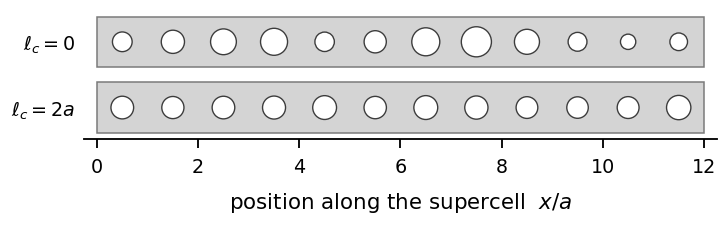

{'figure': 'fig01_supercell', 'width_cm': 17.01, 'height_cm': 5.4, 'dpi': 600, 'border_clear': True}


In [27]:
def figure_schematic():
    cfg, N, mag = C.STRUCTURES["A"], C.N_MAIN, 5.0
    fig, ax = plotting.new_figure(height_cm=6.2, legend_rows=0, left_cm=2.9, bottom_cm=1.9)
    for lc, y0, g in ((0.0, 1.3, 4), (2.0, 0.0, 7)):
        dr = disorder.sample(N, 0.01, lc, np.random.default_rng(C.seed_for(1, g, 0)))
        ax.add_patch(Rectangle((0, y0 - 0.5), N, 1.0, facecolor="#D4D4D4", edgecolor="#7A7A7A", lw=1.0))
        for i in range(N):
            ax.add_patch(Circle((i + 0.5, y0), cfg["r"] + mag * dr[i], facecolor="white",
                                edgecolor="#3C3C3C", lw=0.9))
    ax.set_xlim(-0.25, N + 0.25)
    ax.set_ylim(-0.62, 1.92)
    ax.set_aspect("equal")
    ax.set_yticks([1.3, 0.0])
    ax.set_yticklabels([r"$\ell_c = 0$", r"$\ell_c = 2a$"])
    ax.tick_params(axis="y", length=0)
    ax.spines["left"].set_visible(False)
    ax.set_xticks(range(0, N + 1, 2))
    ax.set_xlabel(r"position along the supercell  $x/a$")
    show(fig, ax, "fig01_supercell")


figure_schematic()

**Figure 2.** Plane-wave cutoff ladder.

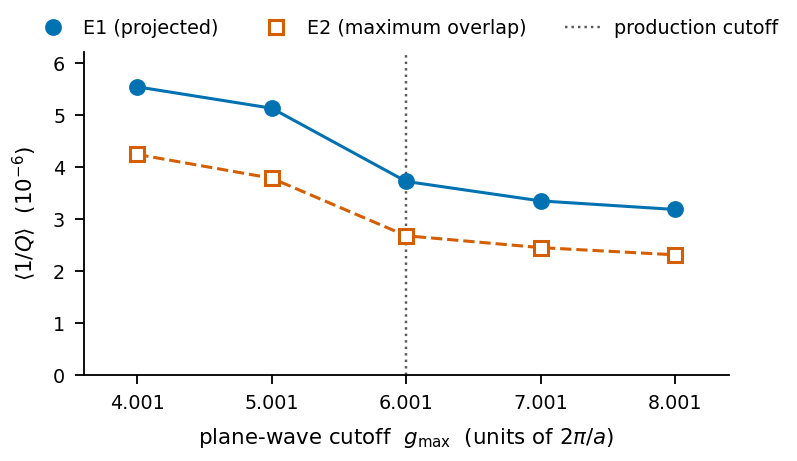

{'figure': 'fig02_cutoff_ladder', 'width_cm': 18.53, 'height_cm': 10.85, 'dpi': 600, 'border_clear': True}


In [28]:
def figure_ladder():
    fig, ax = plotting.new_figure(height_cm=10.5, legend_rows=1)
    g = [r["gmax"] for r in conv["ladder"]]
    ax.axvline(C.GMAX_PROD, color=GREY, ls=":", lw=1.6, zorder=1, label="production cutoff")
    y1 = [1e6 * np.mean(r["inv_q"]) for r in conv["ladder"]]
    y2 = [1e6 * r["inv_q_mode_mean"] for r in conv["ladder"]]
    ax.plot(g, y1, "-", color=OI[0], zorder=2)
    ax.plot(g, y1, MK[0], color=OI[0], ms=10, zorder=3, label="E1 (projected)")
    ax.plot(g, y2, "--", color=OI[1], zorder=2)
    ax.plot(g, y2, MK[1], color=OI[1], ms=9, mfc="white", mew=2, zorder=3,
            label="E2 (maximum overlap)")
    ax.set_ylim(0, 1.12 * max(y1))
    ax.set_xticks(g)
    ax.set_xticklabels([f"{v:g}" for v in g])
    ax.set_xlim(min(g) - 0.4, max(g) + 0.4)
    ax.set_xlabel(r"plane-wave cutoff  $g_{\max}$  (units of $2\pi/a$)")
    ax.set_ylabel(r"$\langle 1/Q \rangle$  ($10^{-6}$)")
    handles, labels = ax.get_legend_handles_labels()
    order = [1, 2, 0]
    plotting.legend_above(fig, ax, [handles[i] for i in order], [labels[i] for i in order], ncol=3)
    show(fig, ax, "fig02_cutoff_ladder")


figure_ladder()

**Figure 3.** Ensemble-mean loss against correlation length on the main grid, with the one-amplitude spectral-overlap model.

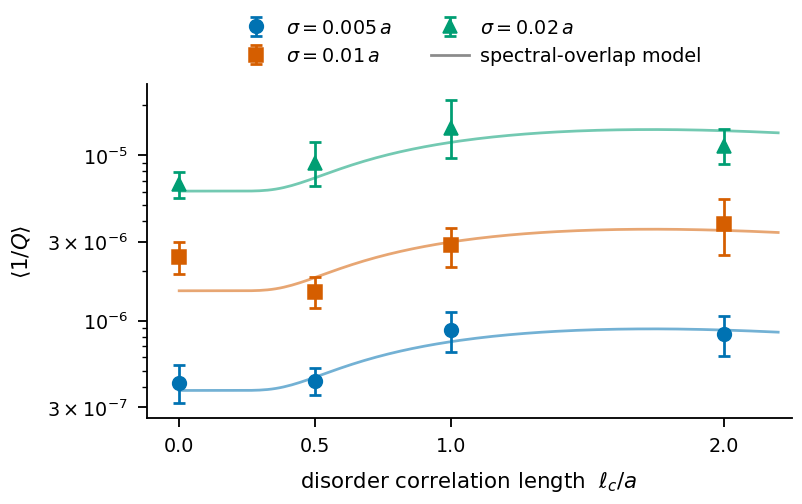

{'figure': 'fig03_correlation_length', 'width_cm': 18.72, 'height_cm': 11.84, 'dpi': 600, 'border_clear': True}


In [29]:
def figure_correlation_length():
    fig, ax = plotting.new_figure(height_cm=11.5, legend_rows=2)
    lct = np.linspace(0.0, 2.2, 150)
    for i, s in enumerate(C.SIGMAS):
        ci = [stats.boot_mean(e1(main[(s, lc)])) for lc in C.LCS]
        y = np.array([c["mean"] for c in ci])
        ax.errorbar(C.LCS, y, yerr=[y - [c["lo"] for c in ci], [c["hi"] for c in ci] - y],
                    fmt=MK[i], color=OI[i], ms=9, lw=0, elinewidth=1.8, capsize=4, capthick=1.8,
                    zorder=3, label=rf"$\sigma = {s}\,a$")
        curve = [A_i * model.channels(C.N_MAIN, s, max(l, 1e-9), f0, fm, gm)[1]
                 + main[(s, 0.0)]["inv_q_clean"] for l in lct]
        ax.plot(lct, curve, "-", color=OI[i], lw=1.8, alpha=0.55, zorder=2)
    ax.set_yscale("log")
    plotting.log_ticks(ax.yaxis, (3e-7, 1e-6, 3e-6, 1e-5, 3e-5))
    ax.set_xlim(-0.12, 2.25)
    ax.set_xticks(C.LCS)
    ax.set_xlabel(r"disorder correlation length  $\ell_c/a$")
    ax.set_ylabel(r"$\langle 1/Q \rangle$")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([], [], color=GREY, lw=1.8, alpha=0.7))
    labels.append("spectral-overlap model")
    plotting.legend_above(fig, ax, handles, labels, ncol=2)
    show(fig, ax, "fig03_correlation_length")


figure_correlation_length()

**Figure 4.** Ratio of the two loss estimators on the main grid.

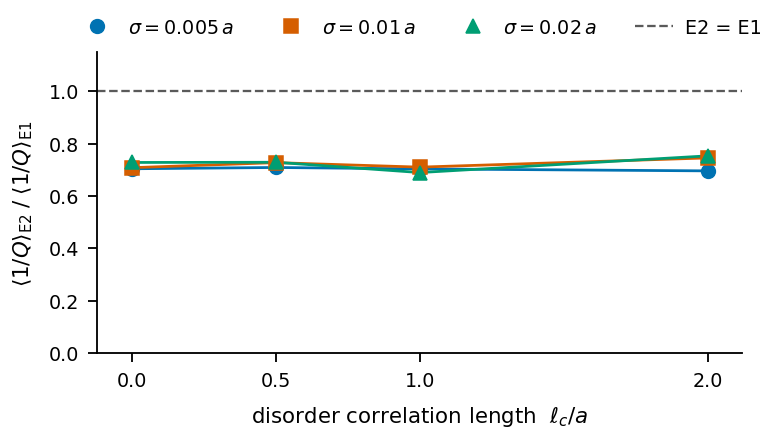

{'figure': 'fig04_estimators', 'width_cm': 18.14, 'height_cm': 10.34, 'dpi': 600, 'border_clear': True}


In [30]:
def figure_estimators():
    fig, ax = plotting.new_figure(height_cm=10.0, legend_rows=1)
    ax.axhline(1.0, color=GREY, ls="--", lw=1.5, zorder=1, label="E2 = E1")
    for i, s in enumerate(C.SIGMAS):
        r = [est_ratio[(s, lc)] for lc in C.LCS]
        ax.plot(C.LCS, r, "-", color=OI[i], lw=1.8, zorder=2)
        ax.plot(C.LCS, r, MK[i], color=OI[i], ms=9, zorder=3, label=rf"$\sigma = {s}\,a$")
    ax.set_ylim(0.0, 1.15)
    ax.set_xlim(-0.12, 2.12)
    ax.set_xticks(C.LCS)
    ax.set_xlabel(r"disorder correlation length  $\ell_c/a$")
    ax.set_ylabel(r"$\langle 1/Q \rangle_{\mathrm{E2}} \;/\; \langle 1/Q \rangle_{\mathrm{E1}}$")
    handles, labels = ax.get_legend_handles_labels()
    plotting.legend_above(fig, ax, handles[1:] + handles[:1], labels[1:] + labels[:1], ncol=4)
    show(fig, ax, "fig04_estimators")


figure_estimators()

**Figure 5.** Distribution of the loss for white and correlated disorder.

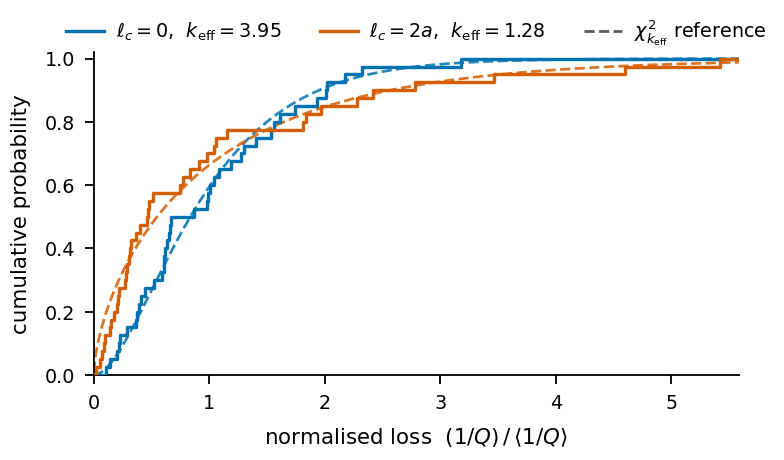

{'figure': 'fig05_distribution', 'width_cm': 18.33, 'height_cm': 10.83, 'dpi': 600, 'border_clear': True}


In [31]:
def figure_distribution():
    fig, ax = plotting.new_figure(height_cm=10.5, legend_rows=1)
    x_max = 1.03 * max(dist[(0.01, lc)]["max_over_mean"] for lc in (0.0, 2.0))
    for i, lc in enumerate((0.0, 2.0)):
        v = e1(main[(0.01, lc)])
        v = np.sort(v / v.mean())
        k = dist[(0.01, lc)]["k_eff"]
        ax.step(np.concatenate([[0], v, [x_max]]),
                np.concatenate([[0], np.arange(1, len(v) + 1) / len(v), [1.0]]),
                where="post", color=OI[i], lw=2.2, zorder=3,
                label=rf"$\ell_c = {lc_text(lc)}$,  $k_{{\mathrm{{eff}}}} = {k:.2f}$")
        x = np.linspace(1e-3, x_max, 400)
        ax.plot(x, sps.chi2.cdf(x * k, k), "--", color=OI[i], lw=1.8, alpha=0.85, zorder=2)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([], [], color=GREY, ls="--", lw=1.8))
    labels.append(r"$\chi^2_{k_{\mathrm{eff}}}$ reference")
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel(r"normalised loss  $(1/Q)\,/\,\langle 1/Q \rangle$")
    ax.set_ylabel("cumulative probability")
    plotting.legend_above(fig, ax, handles, labels, ncol=3)
    show(fig, ax, "fig05_distribution")


figure_distribution()

**Figure 6.** Excess loss against disorder amplitude.

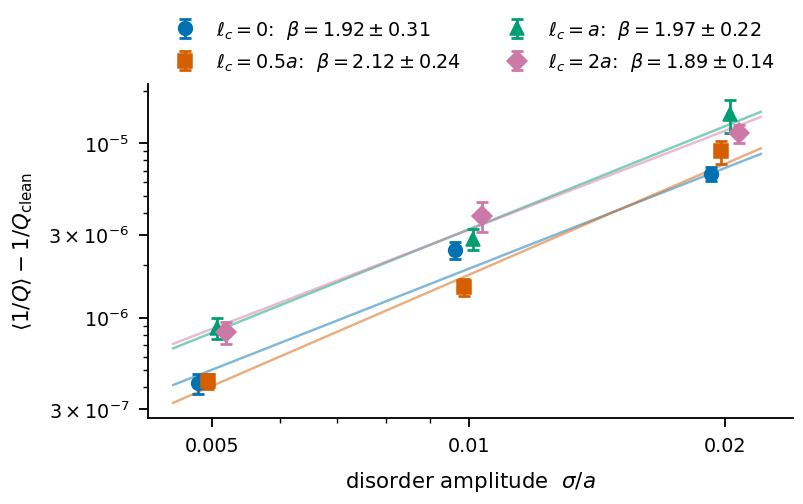

{'figure': 'fig06_amplitude', 'width_cm': 18.72, 'height_cm': 11.84, 'dpi': 600, 'border_clear': True}


In [32]:
def figure_amplitude():
    fig, ax = plotting.new_figure(height_cm=11.5, legend_rows=2)
    xs = np.array(C.SIGMAS)
    for i, lc in enumerate(C.LCS):
        b = beta[lc]
        ax.errorbar(xs * (1 + 0.025 * (i - 1.5)), b["y"], yerr=b["sem"], fmt=MK[i], color=OI[i], ms=9,
                    lw=0, elinewidth=1.8, capsize=4, capthick=1.8, zorder=3,
                    label=rf"$\ell_c = {lc_text(lc)}$:  $\beta = {b['slope']:.2f} \pm {b['se_inflated']:.2f}$")
        xx = np.geomspace(xs[0] * 0.9, xs[-1] * 1.1, 50)
        ax.plot(xx, np.exp(b["intercept"]) * xx ** b["slope"], "-", color=OI[i], lw=1.6, alpha=0.5,
                zorder=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    plotting.log_ticks(ax.yaxis, (3e-7, 1e-6, 3e-6, 1e-5, 3e-5))
    ax.set_xticks(C.SIGMAS)
    ax.set_xticklabels([f"{s:g}" for s in C.SIGMAS])
    ax.set_xlim(0.0042, 0.024)
    ax.set_xlabel(r"disorder amplitude  $\sigma/a$")
    ax.set_ylabel(r"$\langle 1/Q \rangle - 1/Q_{\mathrm{clean}}$")
    plotting.legend_above(fig, ax, ncol=2)
    show(fig, ax, "fig06_amplitude")


figure_amplitude()

**Figure 7.** Enhancement ratio at three supercell sizes with the parameter-free model prediction.

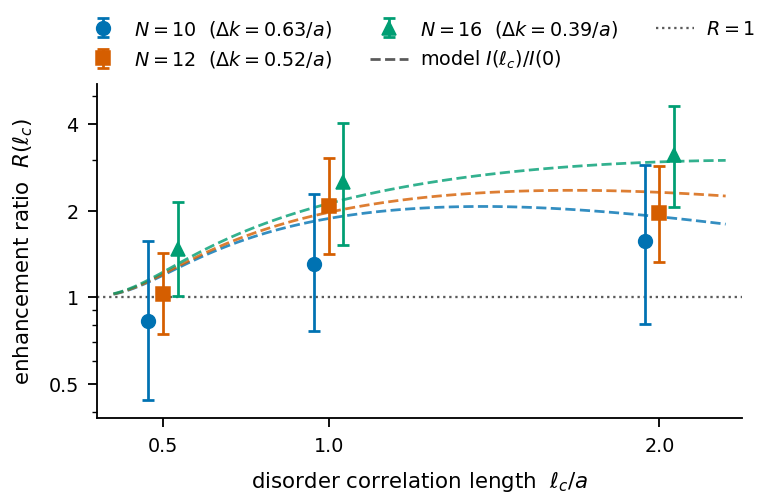

{'figure': 'fig07_supercell_size', 'width_cm': 17.99, 'height_cm': 11.84, 'dpi': 600, 'border_clear': True}


In [33]:
def figure_size():
    fig, ax = plotting.new_figure(height_cm=11.5, legend_rows=2)
    ax.axhline(1.0, color=GREY, ls=":", lw=1.5, zorder=1)
    lct = np.linspace(0.35, 2.2, 120)
    for i, N in enumerate(C.N_SIZES):
        rows = size_rows[N]
        x = np.array([r["lc"] for r in rows]) + 0.045 * (i - 1)
        y = np.array([r["ratio"] for r in rows])
        ax.errorbar(x, y, yerr=[y - [r["lo"] for r in rows], [r["hi"] for r in rows] - y], fmt=MK[i],
                    color=OI[i], ms=9, lw=0, elinewidth=1.8, capsize=4, capthick=1.8, zorder=3,
                    label=rf"$N = {N}$  ($\Delta k = {2 * np.pi / N:.2f}/a$)")
        f0N, fmN, gmN = bands[(N, C.GMAX_PROD)]
        ax.plot(lct, [model.ratio_prediction(N, l, f0N, fmN, gmN) for l in lct], "--", color=OI[i],
                lw=1.8, alpha=0.8, zorder=2)
    handles, labels = ax.get_legend_handles_labels()
    handles += [Line2D([], [], color=GREY, ls="--", lw=1.8), Line2D([], [], color=GREY, ls=":", lw=1.5)]
    labels += [r"model $I(\ell_c)/I(0)$", r"$R = 1$"]
    ax.set_yscale("log")
    plotting.log_ticks(ax.yaxis, (0.5, 1, 2, 4))
    ax.set_ylim(0.38, 5.5)
    ax.set_xlim(0.3, 2.25)
    ax.set_xticks(C.LCS[1:])
    ax.set_xlabel(r"disorder correlation length  $\ell_c/a$")
    ax.set_ylabel(r"enhancement ratio  $R(\ell_c)$")
    plotting.legend_above(fig, ax, handles, labels, ncol=3)
    show(fig, ax, "fig07_supercell_size")


figure_size()

**Figure 8.** Clean-lattice $Q(k)$ of structures A and B at the smallest and largest cutoffs.

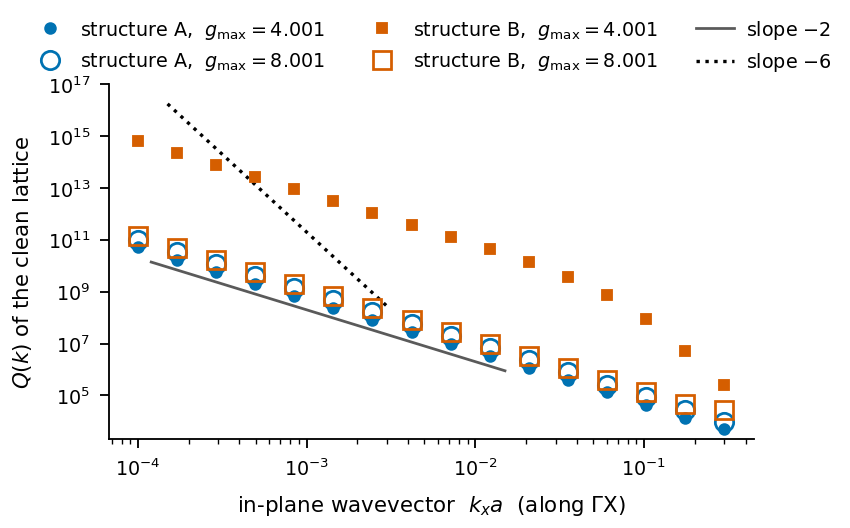

{'figure': 'fig08_momentum_space', 'width_cm': 19.74, 'height_cm': 12.34, 'dpi': 600, 'border_clear': True}


In [34]:
def figure_momentum():
    fig, ax = plotting.new_figure(height_cm=12.0, legend_rows=2)
    for tag, col, mk in (("A", OI[0], "o"), ("B", OI[1], "s")):
        for j, g in enumerate(("4.001", "8.001")):
            q = np.array(momentum["geometries"][tag]["q_full"][g])
            ax.loglog(kf, q, mk, color=col, ms=7 if j == 0 else 12, mfc=col if j == 0 else "none",
                      mew=1.2 if j == 0 else 1.8, zorder=3 + j,
                      label=rf"structure {tag},  $g_{{\max}} = {float(g):g}$")
    kr = np.array([1.2e-4, 1.5e-2])
    ax.loglog(kr, 2e2 * kr ** -2.0, "-", color=GREY, lw=1.8, zorder=2, label=r"slope $-2$")
    kr6 = np.array([1.5e-4, 3e-3])
    ax.loglog(kr6, 2e-7 * kr6 ** -6.0, ":", color="black", lw=2.2, zorder=2, label=r"slope $-6$")
    ax.set_ylim(2e3, 1e17)
    ax.set_xlabel(r"in-plane wavevector  $k_x a$  (along $\Gamma$X)")
    ax.set_ylabel(r"$Q(k)$ of the clean lattice")
    plotting.legend_above(fig, ax, ncol=3)
    show(fig, ax, "fig08_momentum_space")


figure_momentum()

**Figure 9.** Apparent $Q$ enhancement over structure A at $k = 10^{-4}$ against the plane-wave cutoff.

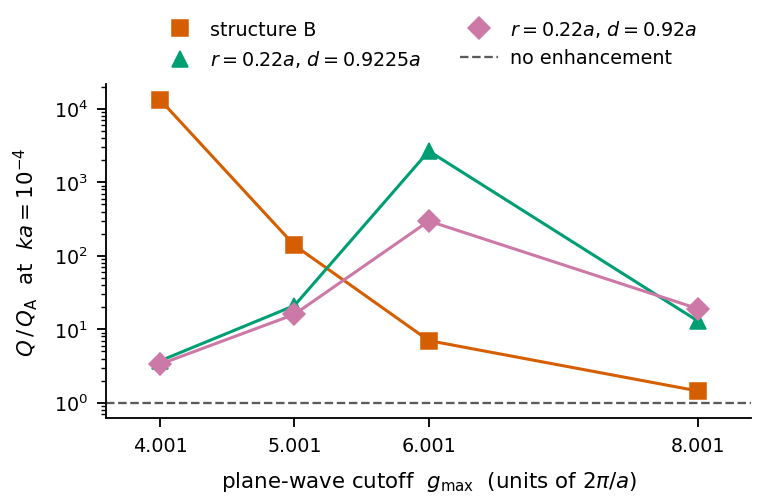

{'figure': 'fig09_apparent_enhancement', 'width_cm': 17.7, 'height_cm': 11.84, 'dpi': 600, 'border_clear': True}


In [35]:
def figure_contrast():
    fig, ax = plotting.new_figure(height_cm=11.5, legend_rows=2)
    ax.axhline(1.0, color=GREY, ls="--", lw=1.5, zorder=1, label="no enhancement")
    labels_map = {"B": "structure B"}
    for i, (label, c) in enumerate(contrast.items()):
        g = [float(k) for k in c]
        name = labels_map.get(label, "")
        if not name:
            geo = momentum["geometries"][label]
            name = rf"$r = {geo['r']:g}a$, $d = {geo['d']:g}a$"
        ax.plot(g, list(c.values()), "-", color=OI[i + 1], lw=2.0, zorder=2)
        ax.plot(g, list(c.values()), MK[i + 1], color=OI[i + 1], ms=10, zorder=3, label=name)
    ax.set_yscale("log")
    ax.set_xticks([float(k) for k in contrast["B"]])
    ax.set_xticklabels([f"{float(k):g}" for k in contrast["B"]])
    ax.set_xlim(3.6, 8.4)
    ax.set_xlabel(r"plane-wave cutoff  $g_{\max}$  (units of $2\pi/a$)")
    ax.set_ylabel(r"$Q\,/\,Q_{\mathrm{A}}$  at  $k a = 10^{-4}$")
    handles, labels = ax.get_legend_handles_labels()
    plotting.legend_above(fig, ax, handles[1:] + handles[:1], labels[1:] + labels[:1], ncol=2)
    show(fig, ax, "fig09_apparent_enhancement")


figure_contrast()
assert len(FIG_QC) == 9 and all(q["border_clear"] for q in FIG_QC)

## 11. Final results

The numbers quoted in the paper are written to `results/summary.json`; the per-case values behind its tables are in the stage records in `results/`. The table below lists the main results.

In [36]:
def ci(d, key="ratio"):
    return [round(d[key], 4), round(d["lo"], 4), round(d["hi"], 4)]


summary = dict(
    disorder_generator=dict(autocov_rms_over_sigma2=generator_rms, max_clip_weight=clip_max),
    survey=dict(n_geometries=len(cand), exponent_range=[float(exps.min()), float(exps.max())],
                n_steeper_than_minus4=int(np.sum(exps < -4))),
    zero_contrast=zero_contrast,
    asymmetry_law=dict(exponent=asym_fit["slope"], se=asym_fit["se_inflated"],
                       q_range=[float(min(1 / inv_q_alpha)), float(max(1 / inv_q_alpha))]),
    rcwa=rcwa_summary,
    ladder=dict(steps=[dict(g_from=s["g_from"], g_to=s["g_to"], d_inv_q=s["d_inv_q"], d_f=s["d_f"],
                            passed=s["passed"], paired=ci(s["paired"])) for s in steps],
                plateau=plateau, drift_4_to_8=float(ladder_drift),
                means={f"{r['gmax']:g}": dict(E1=float(np.mean(r["inv_q"])), E2=r["inv_q_mode_mean"])
                       for r in conv["ladder"]}),
    guided_modes=dict(ensemble_change=float(enrich_change), frequency_change=float(enrich_df),
                      max_added_block_weight=float(block_weight_max)),
    gamma_spectrum=gamma_spectrum,
    clean_mode=dict(f0=main[(0.01, 0.0)]["f0"], Q=1 / main[(0.01, 0.0)]["inv_q_clean"],
                    f0_check=check[0.0]["f0"], Q_check=1 / check[0.0]["inv_q_clean"]),
    ensembles=dict(n_ensembles=len(all_ens), n_realisations=int(n_real),
                   min_overlap=float(min_overlap), radius_floor_hits=int(floor_hits),
                   spot_check_max_rel_diff=float(spot_max),
                   q_range=[float(1 / max(e1(r).mean() for r in all_ens if r["gmax"] == C.GMAX_PROD)),
                            float(1 / min(e1(r).mean() for r in all_ens if r["gmax"] == C.GMAX_PROD))]),
    ratios=[dict(sigma=r["sigma"], lc=r["lc"], E1=ci(r["E1"]), E2=round(r["E2"]["ratio"], 4),
                 median=ci(r["median"]), z=round(r["z"], 3), bonferroni=r["bonferroni"])
            for r in ratio_rows],
    ratio_counts=dict(excludes_one=int(n_excl), bonferroni=int(n_bonf9), same_sign=int(n_same)),
    pooled={f"{lc:g}": dict(R=ci(p, "R"), z=p["z"], Q=p["Q"], p_heterogeneity=p["p_heterogeneity"],
                            I2=p["I2"], bonferroni=p["bonferroni"],
                            median=ci(pooled_median[lc], "R"),
                            halves=[halves[(lc, "first")]["R"], halves[(lc, "second")]["R"]])
            for lc, p in pooled.items()},
    two_way=dict(R={f"{lc:g}": ci(v, "R") for lc, v in two_way.items()},
                 z={f"{lc:g}": v["z"] for lc, v in two_way.items()},
                 chi2=chi2_tw, dof=dof_tw, p=float(sps.chi2.sf(chi2_tw, dof_tw)),
                 beta=[beta_tw["slope"], beta_tw["se_inflated"]]),
    coverage=coverage,
    estimators=dict(ratio_range=[float(vals.min()), float(vals.max())], lc_means=lc_means,
                    mean=float(vals.mean()), lc_trend=float(est_slope)),
    distribution=dict(k_eff_median=float(np.median(k_all)), k_eff_range=[float(k_all.min()), float(k_all.max())],
                      skew_range=[float(skew_all.min()), float(skew_all.max())],
                      k_eff_sigma001={f"{lc:g}": dist[(0.01, lc)]["k_eff"] for lc in C.LCS}),
    beta={f"{lc:g}": dict(beta=b["slope"], se=b["se_inflated"], se_nominal=b["se"], chi2_red=b["chi2_red"],
                          consistent=b["consistent"]) for lc, b in beta.items()},
    beta_pooled=[beta_pooled, beta_pooled_se],
    model=dict(A_i=A_i, A_i_se=A_i_se, chi2_red=chi2_1 / dof_1, within25=int(within25),
               two_channel=dict(A_d=A_d2, A_d_se=se_d2, A_i=A_i2, A_i_se=se_i2, cond=cond2),
               ratio_model={f"{lc:g}": r_model[lc] for lc in r_model},
               ratio_model_g8={f"{lc:g}": r_model8[lc] for lc in r_model8}),
    size=dict(rows={str(N): [dict(lc=r["lc"], R=ci(r), model=r["model"]) for r in rows]
                    for N, rows in size_rows.items()},
              r_hi={str(N): v for N, v in r_hi.items()}, r_hi_exponent=[rhi_fit["slope"], rhi_fit["se_inflated"]],
              amplitude={str(N): v for N, v in amp_by_N.items()},
              amplitude_exponent=[amp_fit["slope"], amp_fit["se_inflated"]],
              lorentzian_m1={str(N): v for N, v in lor1.items()}, white_loss_exponent=white_fit["slope"],
              white_loss={str(N): float(e1(size[(N, 0.0)]).mean()) for N in C.N_SIZES}),
    cutoff_check={f"{lc:g}": dict(shift=ci(v["shift"]), **({"R6": v["R6"], "R8": v["R8"],
                                                            "double": ci(v["double"])} if lc > 0 else {}))
                  for lc, v in cutoff.items()},
    momentum=dict(diagnostic=diag, contrast=contrast),
    figures=FIG_QC,
)
records.save(RESULTS / "summary.json", summary)

table = [("BIC of structure A: f0, clean Q at k = 1e-4",
          f"{summary['clean_mode']['f0']:.4f}, {summary['clean_mode']['Q']:.2e}"),
         ("Largest clipped spectral weight", f"{clip_max:.1e}"),
         ("Survey: geometries / steeper than k^-4", f"{len(cand)} / {int(np.sum(exps < -4))}"),
         ("Asymmetry law exponent", f"{asym_fit['slope']:.3f} +/- {asym_fit['se_inflated']:.3f}"),
         ("RCWA worst |dQ|/Q, Q range", f"{rcwa_summary['worst_dev']:.3f}, {rcwa_summary['q_range'][0]:.0f}-{rcwa_summary['q_range'][1]:.0f}"),
         ("Cutoff plateau (g_max)", f"{plateau:g}"),
         ("Largest weight on added guided modes", f"{block_weight_max:.1e}"),
         ("Realisations / smallest overlap", f"{n_real} / {min_overlap:.4f}"),
         ("Q of the ensemble means (production cutoff)",
          f"{summary['ensembles']['q_range'][0]:.1e} to {summary['ensembles']['q_range'][1]:.1e}")]
for lc, p in pooled.items():
    t = two_way[lc]
    table.append((f"R({lc:g}a): two-way fit; random-effects pool (heterogeneity p)",
                  f"{t['R']:.2f} [{t['lo']:.2f}, {t['hi']:.2f}]; {p['R']:.2f} [{p['lo']:.2f}, {p['hi']:.2f}] "
                  f"(p = {p['p_heterogeneity']:.3f})"))
table += [("Pooled amplitude exponent", f"{beta_pooled:.2f} +/- {beta_pooled_se:.2f}"),
          ("One-amplitude model: chi2/dof, within 25%", f"{chi2_1 / dof_1:.2f}, {within25}/12"),
          ("R_hi growth with N", f"N^{rhi_fit['slope']:.2f} +/- {rhi_fit['se_inflated']:.2f}"),
          ("Model amplitude drift with N", f"N^{amp_fit['slope']:.2f} +/- {amp_fit['se_inflated']:.2f}"),
          ("Structure B asymptotic exponent (g_max 4.001, 8.001)",
           f"{diag['B']['4.001']['exponent']:.3f}, {diag['B']['8.001']['exponent']:.3f}"),
          ("Apparent enhancement of B (g_max 4.001 to 8.001)",
           f"{contrast['B']['4.001']:.0f} to {contrast['B']['8.001']:.1f}")]
width = max(len(a) for a, _ in table)
for a, b in table:
    print(f"{a:<{width}}  {b}")

BIC of structure A: f0, clean Q at k = 1e-4                  0.3242, 7.03e+10
Largest clipped spectral weight                              5.4e-03
Survey: geometries / steeper than k^-4                       110 / 0
Asymmetry law exponent                                       2.011 +/- 0.010
RCWA worst |dQ|/Q, Q range                                   0.043, 172-17961
Cutoff plateau (g_max)                                       8.001
Largest weight on added guided modes                         1.8e-27
Realisations / smallest overlap                              680 / 0.9862
Q of the ensemble means (production cutoff)                  6.8e+04 to 3.1e+06
R(0.5a): two-way fit; random-effects pool (heterogeneity p)  0.90 [0.67, 1.21]; 0.94 [0.60, 1.48] (p = 0.003)
R(1a): two-way fit; random-effects pool (heterogeneity p)    1.69 [1.19, 2.39]; 1.72 [1.13, 2.61] (p = 0.034)
R(2a): two-way fit; random-effects pool (heterogeneity p)    1.69 [1.21, 2.35]; 1.75 [1.42, 2.16] (p = 0.762)
Pooled am